In [1]:
import pandas as pd
import re

real = pd.read_csv("D:/KLAUS/Vis_Final_Project/real_feature_output/real_features.csv")
fake = pd.read_csv("D:/KLAUS/Vis_Final_Project/fake_feature_output/fake_features.csv")

real["type"] = "real"
fake["type"] = "fake"

df = pd.concat([real, fake], ignore_index=True)

# keep only actual feature columns: f000, f001, ..., f127
feature_cols = [c for c in df.columns if re.fullmatch(r"f\d{3}", c)]

X = df[feature_cols].values
y = df["type"].values

C:\Users\hp\AppData\Local\Temp\ipykernel_34924\3150500231.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  real["type"] = "real"
C:\Users\hp\AppData\Local\Temp\ipykernel_34924\3150500231.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  fake["type"] = "fake"


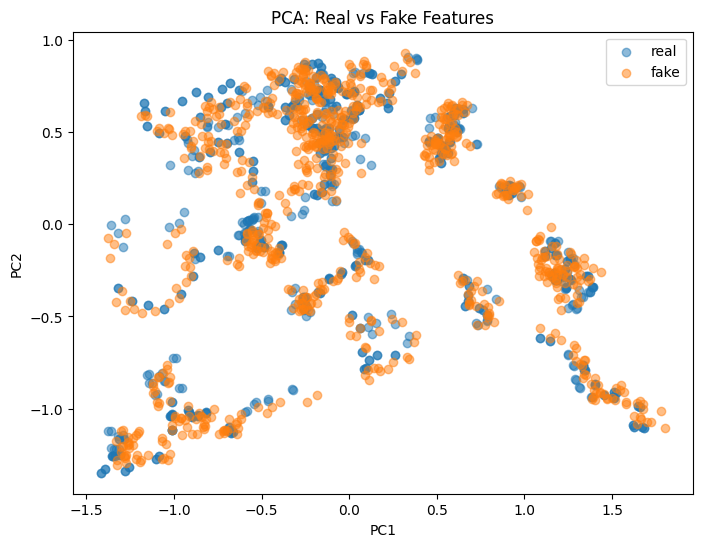

In [2]:
# 2D PCA

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

for label in ["real", "fake"]:
    idx = (y == label)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: Real vs Fake Features")
plt.legend()
plt.show()

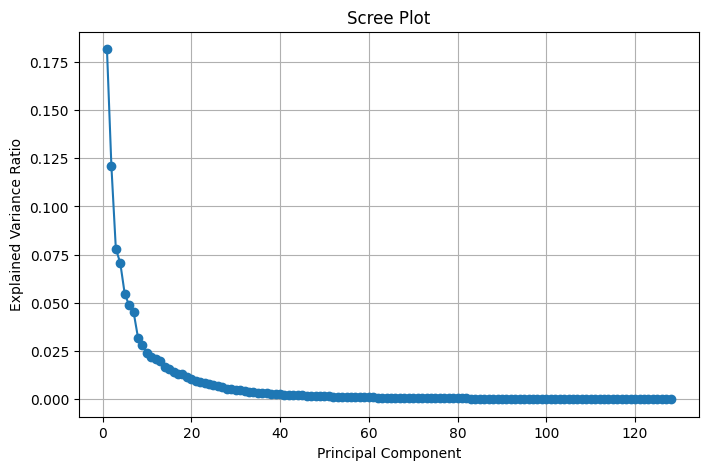

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Fit PCA with all components
pca_full = PCA()
pca_full.fit(X)

explained_variance = pca_full.explained_variance_ratio_

plt.figure(figsize=(8,5))

plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.grid(True)
plt.show()

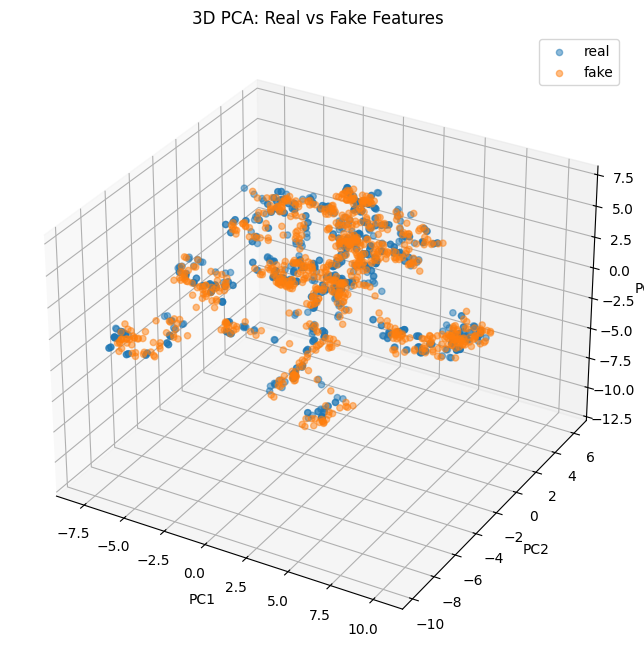

In [55]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Apply PCA (3 components)
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# Create 3D plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# Plot real vs fake
for label, color in zip(["real", "fake"], ["blue", "red"]):
    idx = (y == label)
    ax.scatter(
        X_pca[idx, 0],
        X_pca[idx, 1],
        X_pca[idx, 2],
        label=label,
        alpha=0.5
    )

# Labels
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D PCA: Real vs Fake Features")

ax.legend()

plt.show()

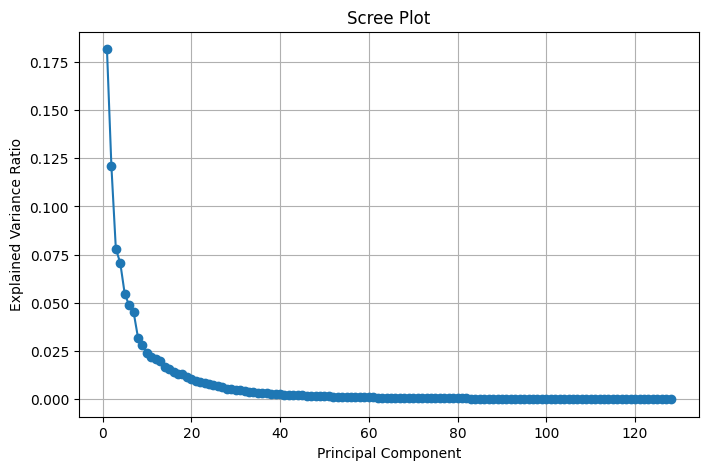

In [5]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Fit PCA on all components
pca_full = PCA()
pca_full.fit(X)

explained_variance = pca_full.explained_variance_ratio_

# Scree plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")

plt.grid(True)
plt.show()

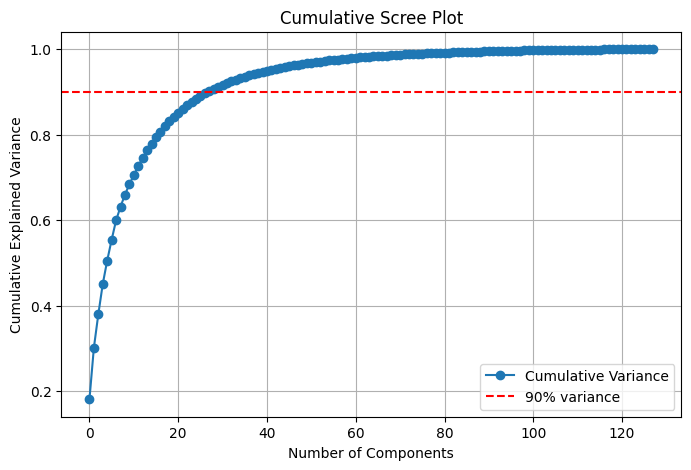

In [6]:
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(cumulative_variance, marker='o', label="Cumulative Variance")

plt.axhline(y=0.9, color='r', linestyle='--', label="90% variance")

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Scree Plot")

plt.legend()
plt.grid(True)
plt.show()

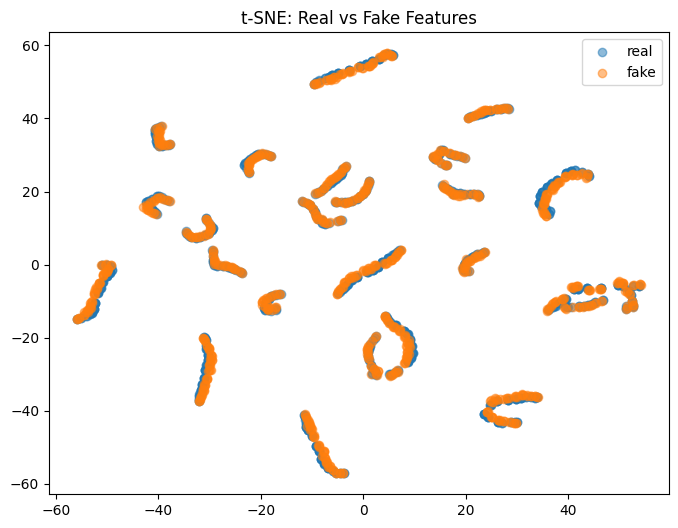

In [7]:
# tsne

from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8,6))

for label in ["real", "fake"]:
    idx = (y == label)
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=label, alpha=0.5)

plt.title("t-SNE: Real vs Fake Features")
plt.legend()
plt.show()

C:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


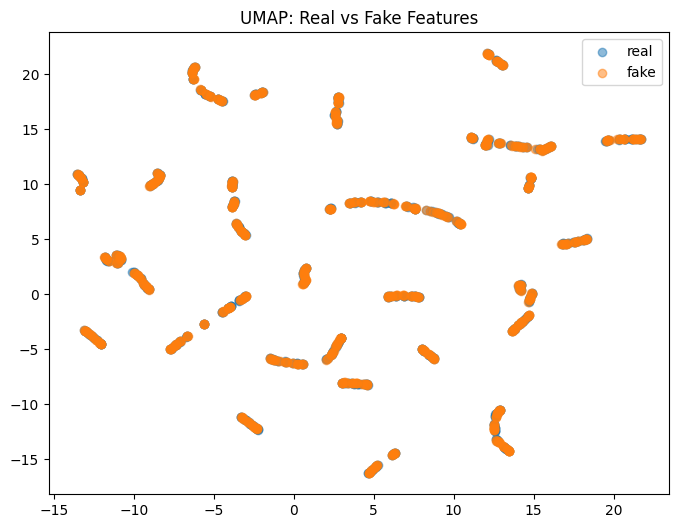

In [8]:
import umap

reducer = umap.UMAP(n_neighbors=15, min_dist=0.1)
X_umap = reducer.fit_transform(X)

plt.figure(figsize=(8,6))

for label in ["real", "fake"]:
    idx = (y == label)
    plt.scatter(X_umap[idx, 0], X_umap[idx, 1], label=label, alpha=0.5)

plt.title("UMAP: Real vs Fake Features")
plt.legend()
plt.show()

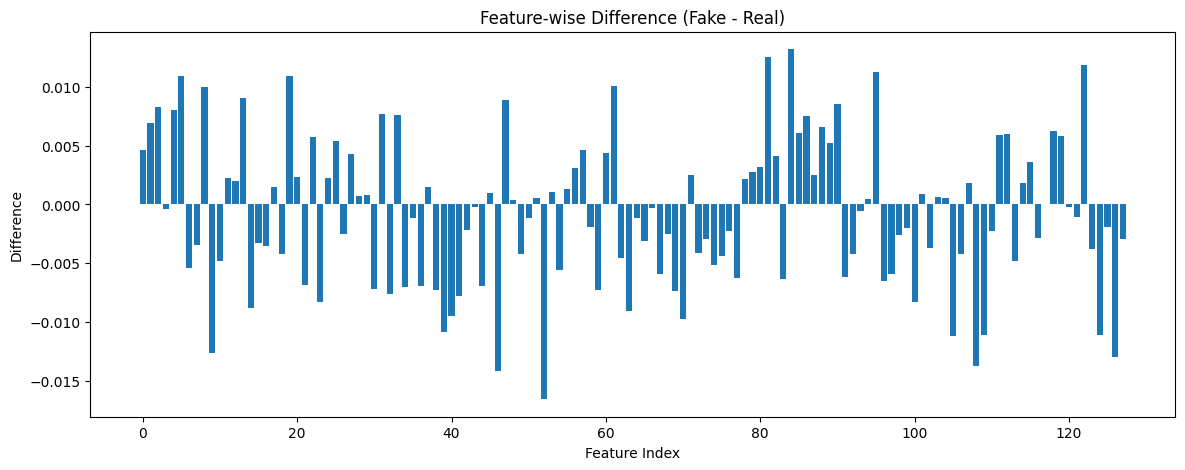

In [9]:
import numpy as np
import matplotlib.pyplot as plt

real_mean = real[feature_cols].mean()
fake_mean = fake[feature_cols].mean()

diff = fake_mean - real_mean

plt.figure(figsize=(14,5))
plt.bar(range(len(diff)), diff)
plt.title("Feature-wise Difference (Fake - Real)")
plt.xlabel("Feature Index")
plt.ylabel("Difference")
plt.show()

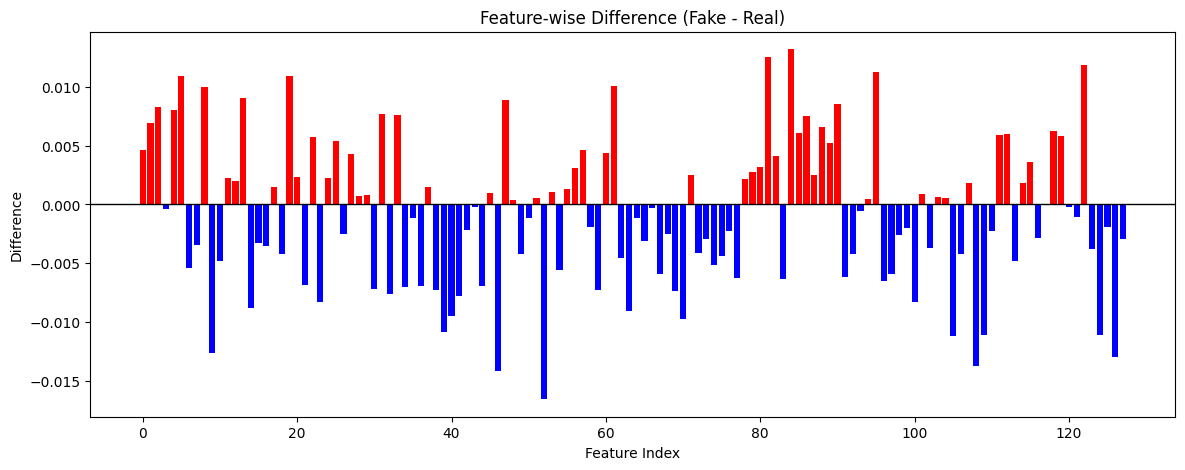

In [10]:
import numpy as np
import matplotlib.pyplot as plt

real_mean = real[feature_cols].mean()
fake_mean = fake[feature_cols].mean()

diff = fake_mean - real_mean

# Colors: red = fake higher, blue = real higher
colors = ["red" if d > 0 else "blue" for d in diff]

plt.figure(figsize=(14,5))
plt.bar(range(len(diff)), diff, color=colors)

plt.axhline(0, color='black', linewidth=1)

plt.title("Feature-wise Difference (Fake - Real)")
plt.xlabel("Feature Index")
plt.ylabel("Difference")

plt.show()

In [11]:
threshold = 0.01  # you can adjust this

significant = np.sum(np.abs(diff.values) > threshold)

print("Significantly different features:", significant)
print("Out of total features:", len(diff))

Significantly different features: 16
Out of total features: 128


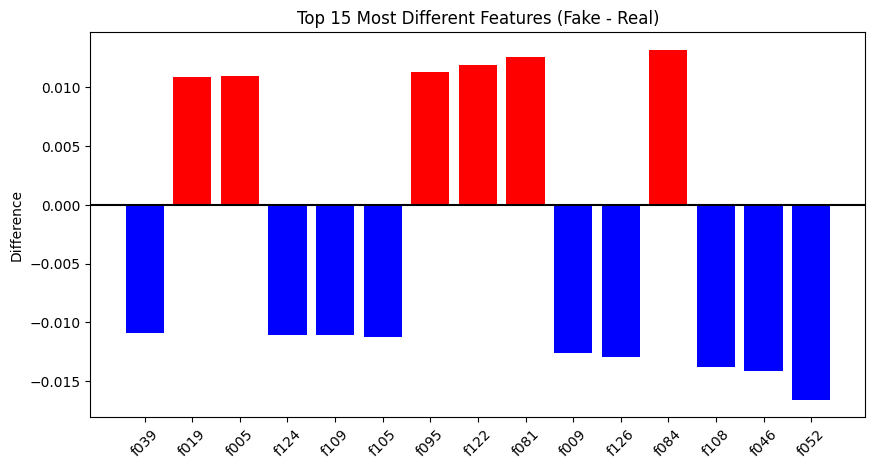

In [12]:
# Get top 15 most different features
top_k = 15
idx_sorted = np.argsort(np.abs(diff.values))[-top_k:]

plt.figure(figsize=(10,5))

colors = ["red" if diff.iloc[i] > 0 else "blue" for i in idx_sorted]

plt.bar(range(top_k), diff.iloc[idx_sorted], color=colors)

plt.xticks(range(top_k), [feature_cols[i] for i in idx_sorted], rotation=45)

plt.axhline(0, color='black')

plt.title("Top 15 Most Different Features (Fake - Real)")
plt.ylabel("Difference")
plt.show()

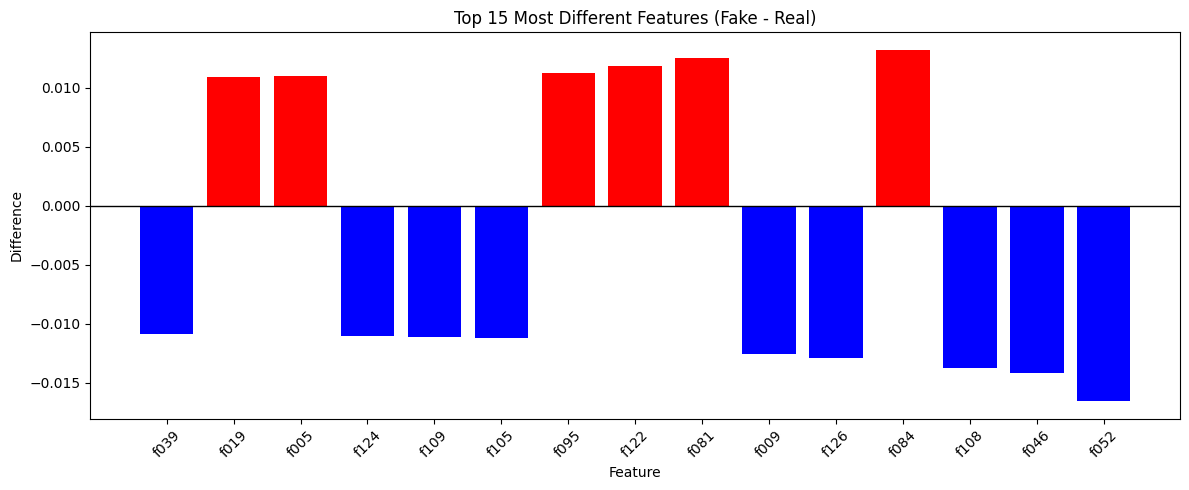

In [13]:
top_k = 15

# indices of top-k absolute differences
idx_sorted = np.argsort(np.abs(diff.values))[-top_k:]

# sort top-k among themselves
idx_sorted = idx_sorted[np.argsort(np.abs(diff.values[idx_sorted]))]

plt.figure(figsize=(12,5))

vals = diff.iloc[idx_sorted]
colors = ["red" if v > 0 else "blue" for v in vals]

plt.bar(range(top_k), vals, color=colors)

plt.xticks(range(top_k), [feature_cols[i] for i in idx_sorted], rotation=45)
plt.axhline(0, color='black', linewidth=1)

plt.title("Top 15 Most Different Features (Fake - Real)")
plt.xlabel("Feature")
plt.ylabel("Difference")

plt.tight_layout()
plt.show()

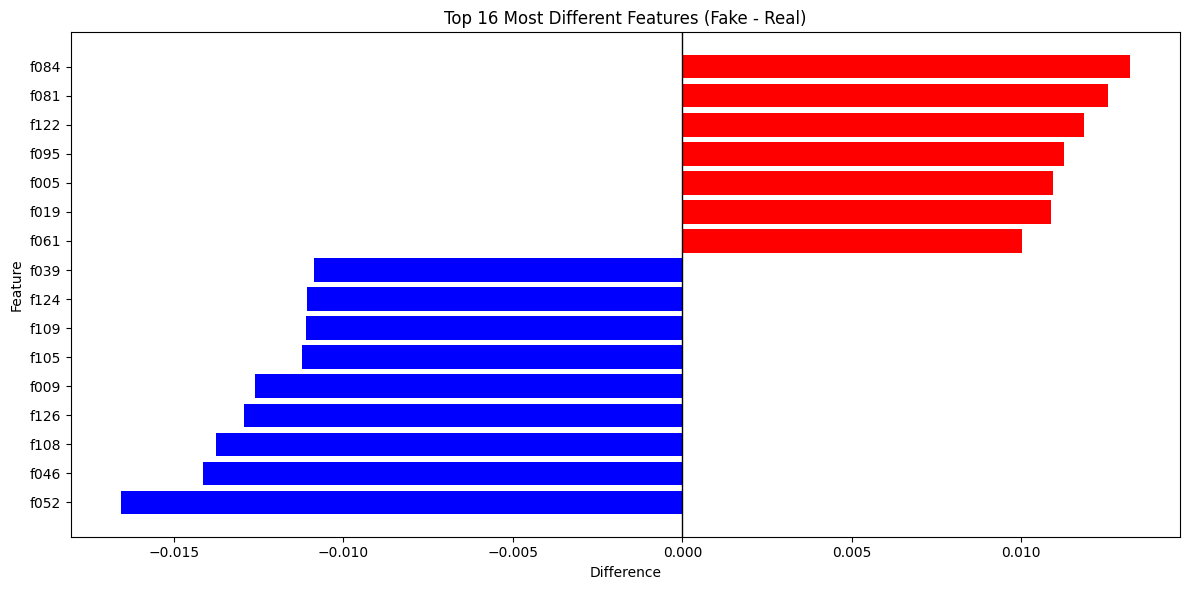

In [14]:
top_k = 16

idx_sorted = np.argsort(np.abs(diff.values))[-top_k:]
vals = diff.iloc[idx_sorted]

# sort by actual signed value for visual clarity
order = np.argsort(vals.values)
vals = vals.iloc[order]
labels = [feature_cols[i] for i in idx_sorted[order]]

colors = ["red" if v > 0 else "blue" for v in vals]

plt.figure(figsize=(12,6))
bars = plt.barh(labels, vals, color=colors)

plt.axvline(0, color='black', linewidth=1)
plt.title("Top 16 Most Different Features (Fake - Real)")
plt.xlabel("Difference")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

[('f052', -0.016557479653446977), ('f046', -0.014151680438699493), ('f108', -0.013746364778691927), ('f126', -0.01294578591786616), ('f009', -0.012596106342083344), ('f105', -0.011224045958354814), ('f109', -0.011105755478099763), ('f124', -0.011069475242045462), ('f039', -0.010867652738484834), ('f070', -0.009699351677434343)]
[('f047', 0.008919892324734849), ('f013', 0.009031999501565665), ('f008', 0.009988888241136357), ('f061', 0.010036054930530305), ('f019', 0.01089185225939394), ('f005', 0.0109465262572601), ('f095', 0.011274745523601026), ('f122', 0.011862390207323256), ('f081', 0.012545813514558081), ('f084', 0.01319707746611741)]


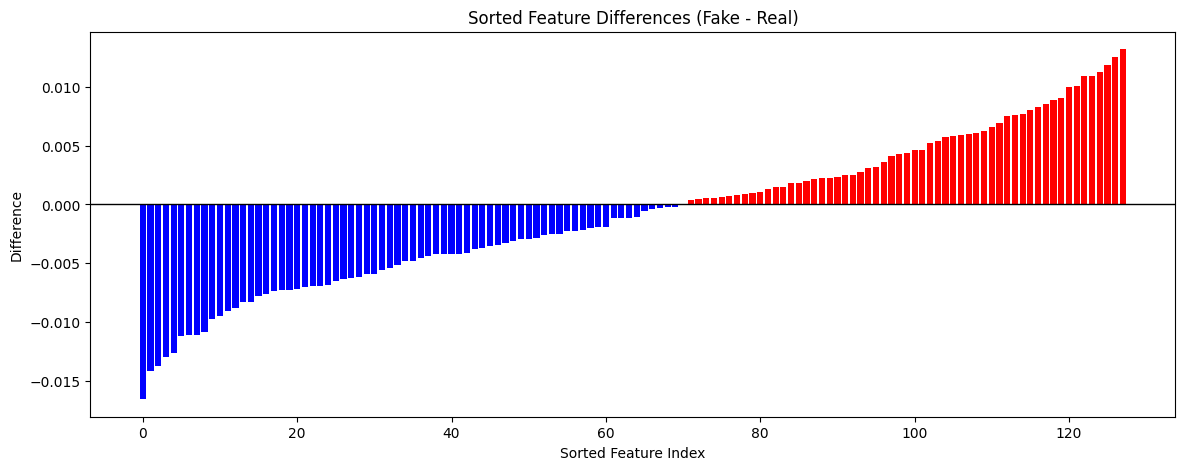

In [15]:
sorted_diff = np.sort(diff.values)

plt.figure(figsize=(14,5))
colors = ["red" if d > 0 else "blue" for d in sorted_diff]

plt.bar(range(len(sorted_diff)), sorted_diff, color=colors)
plt.axhline(0, color='black', linewidth=1)

plt.title("Sorted Feature Differences (Fake - Real)")
plt.xlabel("Sorted Feature Index")
plt.ylabel("Difference")

sorted_idx = np.argsort(diff.values)
sorted_diff = diff.iloc[sorted_idx]
sorted_features = [feature_cols[i] for i in sorted_idx]

print(list(zip(sorted_features[:10], sorted_diff[:10])))
print(list(zip(sorted_features[-10:], sorted_diff[-10:])))

plt.show()

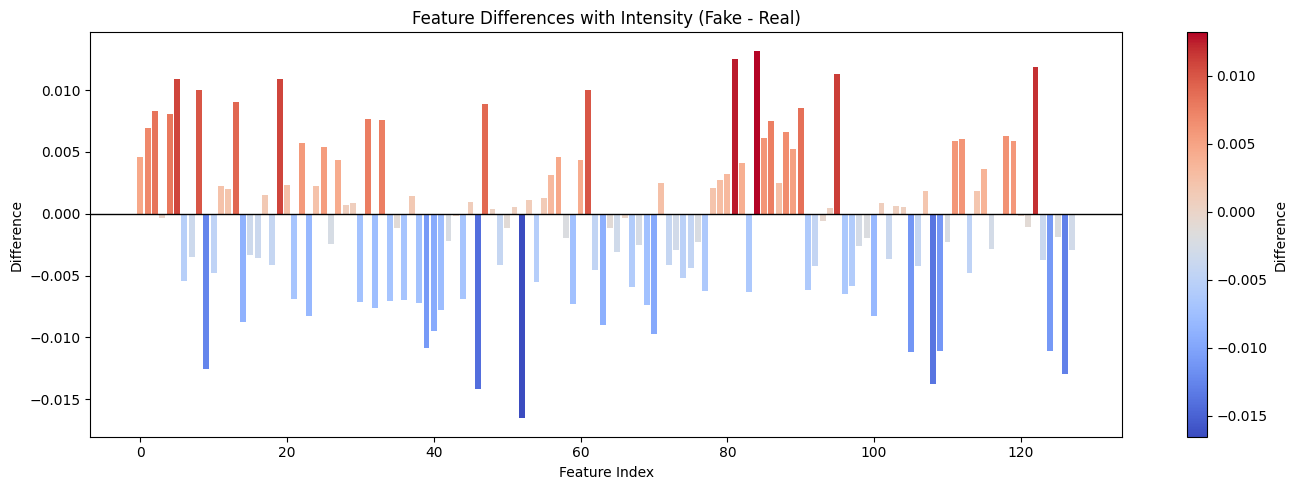

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Convert to numpy array
diff_values = diff.values

# Normalize values for color mapping
norm = plt.Normalize(vmin=diff_values.min(), vmax=diff_values.max())

# Colormap
cmap = cm.coolwarm
colors = cmap(norm(diff_values))

# Create figure and axis (IMPORTANT)
fig, ax = plt.subplots(figsize=(14,5))

# Bar plot
ax.bar(range(len(diff_values)), diff_values, color=colors)

# Zero reference line
ax.axhline(0, color='black', linewidth=1)

# Labels and title
ax.set_title("Feature Differences with Intensity (Fake - Real)")
ax.set_xlabel("Feature Index")
ax.set_ylabel("Difference")

# Create colorbar properly
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig.colorbar(sm, ax=ax, label="Difference")

# Layout
plt.tight_layout()
plt.show()

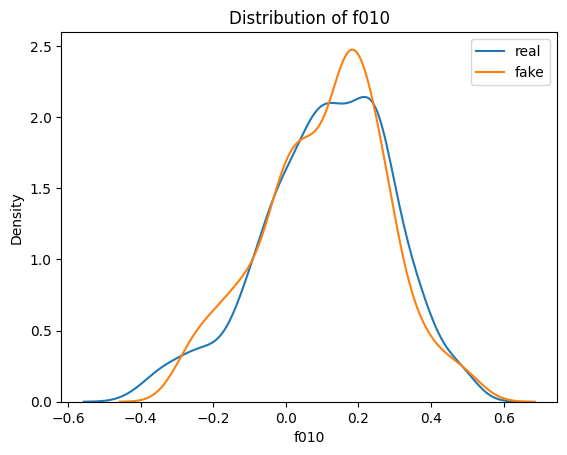

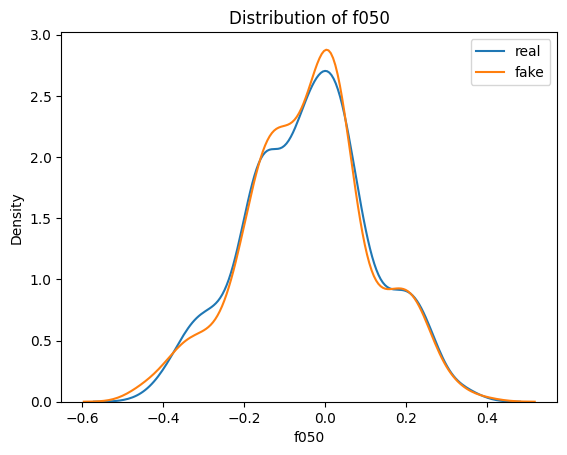

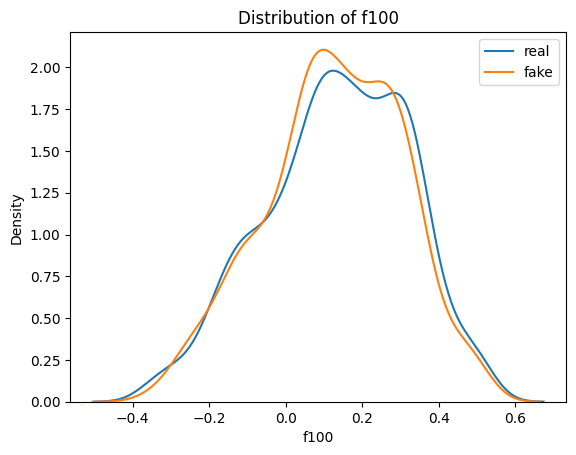

In [11]:
import seaborn as sns

for f in ["f010", "f050", "f100"]:
    plt.figure()
    sns.kdeplot(real[f], label="real")
    sns.kdeplot(fake[f], label="fake")
    plt.title(f"Distribution of {f}")
    plt.legend()
    plt.show()

High difference features: ['f126', 'f084', 'f108', 'f046', 'f052']


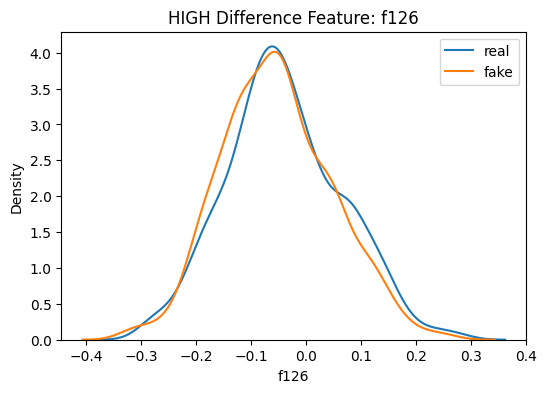

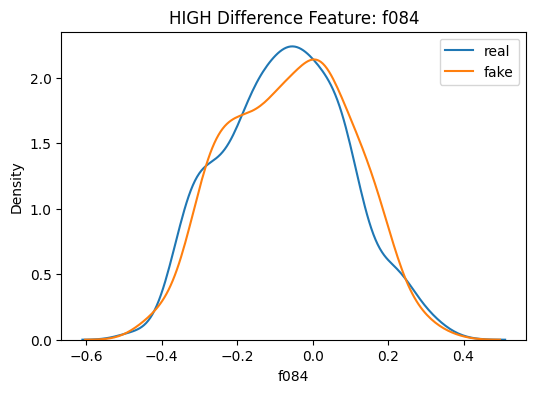

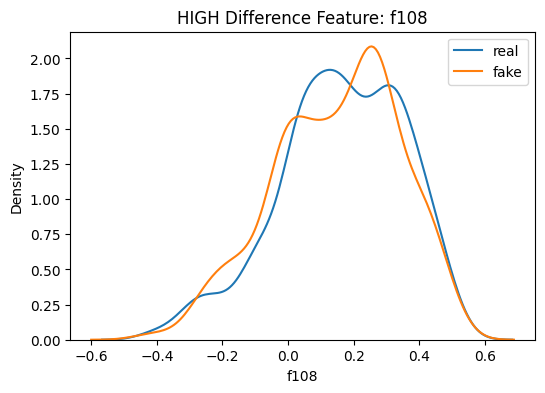

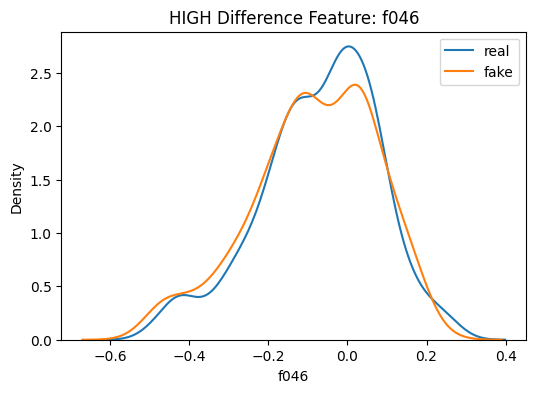

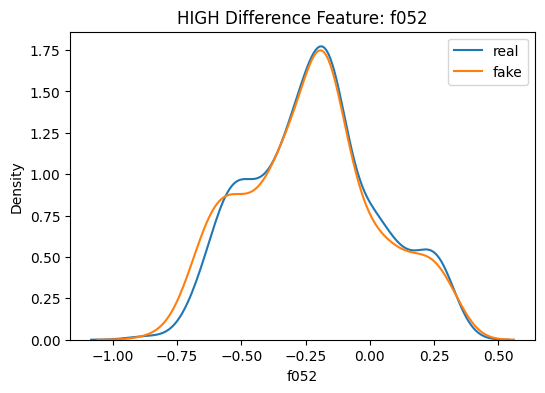

Low difference features: ['f003', 'f028', 'f029', 'f043', 'f045']


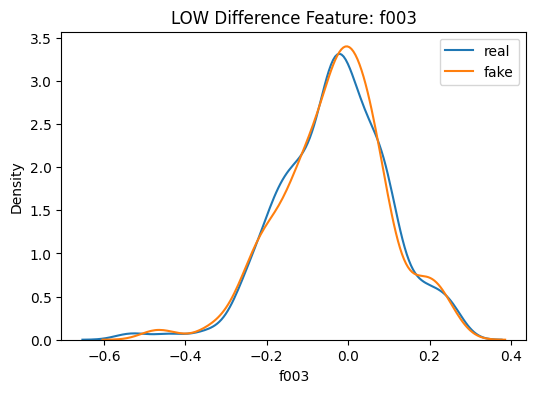

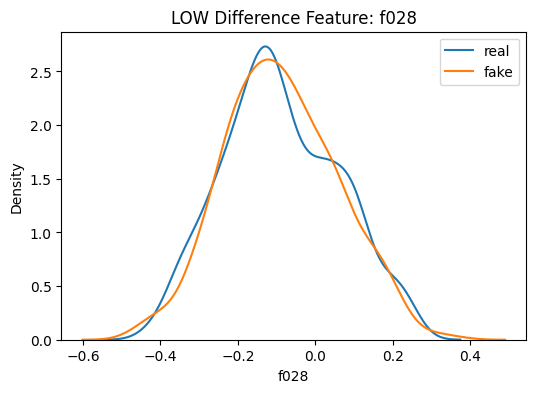

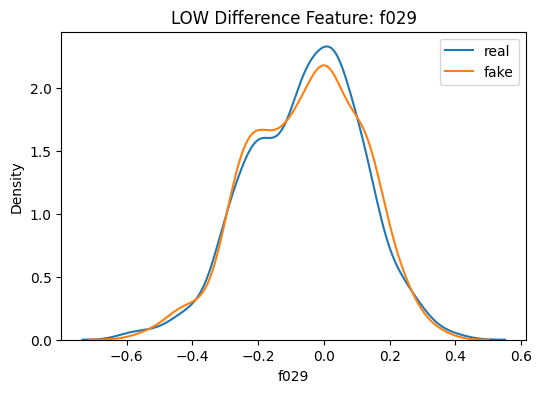

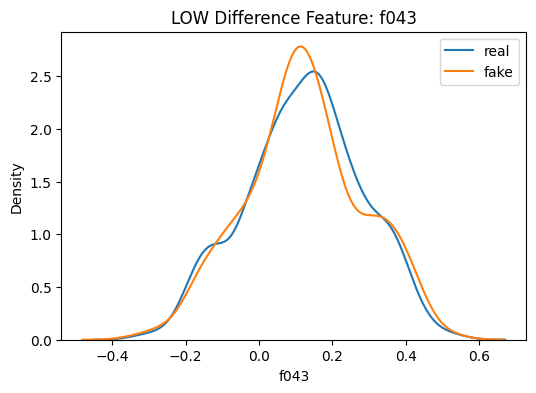

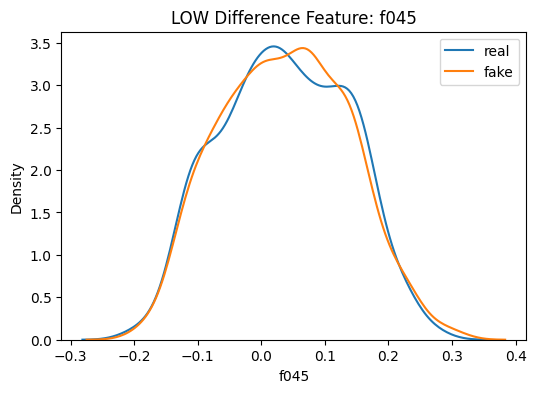

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

diff_values = diff.values

# -------------------------------
# 1. Get features > 0.01 (large difference)
# -------------------------------
high_idx = np.where(np.abs(diff_values) > 0.01)[0]

# pick top 5 from them (largest)
high_idx = high_idx[np.argsort(np.abs(diff_values[high_idx]))[-5:]]

high_features = [feature_cols[i] for i in high_idx]


# -------------------------------
# 2. Get features < 0.005 (small difference)
# -------------------------------
low_idx = np.where(np.abs(diff_values) < 0.001)[0]

# pick 5 random (or first 5)
low_idx = low_idx[:5]

low_features = [feature_cols[i] for i in low_idx]


# -------------------------------
# 3. Plot HIGH difference features
# -------------------------------
print("High difference features:", high_features)

for f in high_features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(real[f], label="real")
    sns.kdeplot(fake[f], label="fake")
    plt.title(f"HIGH Difference Feature: {f}")
    plt.legend()
    plt.show()


# -------------------------------
# 4. Plot LOW difference features
# -------------------------------
print("Low difference features:", low_features)

for f in low_features:
    plt.figure(figsize=(6,4))
    sns.kdeplot(real[f], label="real")
    sns.kdeplot(fake[f], label="fake")
    plt.title(f"LOW Difference Feature: {f}")
    plt.legend()
    plt.show()

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.6214511041009464


In [13]:
from scipy.spatial.distance import cdist

dist = cdist(real[feature_cols], fake[feature_cols])
print("Mean distance:", dist.mean())

Mean distance: 2.5022652735486215


In [24]:
import re
import numpy as np
import pandas as pd

real = pd.read_csv("D:/KLAUS/Vis_Final_Project/real_feature_output/real_features.csv")
fake = pd.read_csv("D:/KLAUS/Vis_Final_Project/fake_feature_output/fake_features.csv")

feature_cols = [c for c in real.columns if re.fullmatch(r"f\d{3}", c)]

X_real = real[feature_cols].to_numpy(dtype=float)
X_fake = fake[feature_cols].to_numpy(dtype=float)

print(X_real.shape, X_fake.shape)

(792, 128) (792, 128)


In [25]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# fake -> nearest real
nn_real = NearestNeighbors(n_neighbors=1, metric="euclidean")
nn_real.fit(X_real)

dist_fake_to_real, idx_fake_to_real = nn_real.kneighbors(X_fake)

# real -> nearest real (use 2 neighbors because first neighbor is itself)
nn_real2 = NearestNeighbors(n_neighbors=2, metric="euclidean")
nn_real2.fit(X_real)

dist_real_to_real, idx_real_to_real = nn_real2.kneighbors(X_real)

# take second column because first is self-distance = 0
real_baseline = dist_real_to_real[:, 1]
fake_to_real = dist_fake_to_real[:, 0]

print("Mean fake->real distance:", fake_to_real.mean())
print("Mean real->real distance:", real_baseline.mean())

Mean fake->real distance: 0.4713383322766569
Mean real->real distance: 0.08550166790993283


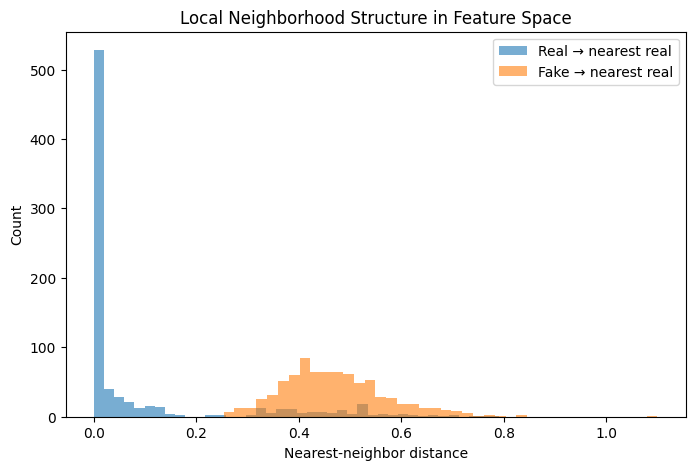

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(real_baseline, bins=40, alpha=0.6, label="Real → nearest real")
plt.hist(fake_to_real, bins=40, alpha=0.6, label="Fake → nearest real")

plt.xlabel("Nearest-neighbor distance")
plt.ylabel("Count")
plt.title("Local Neighborhood Structure in Feature Space")
plt.legend()
plt.show()

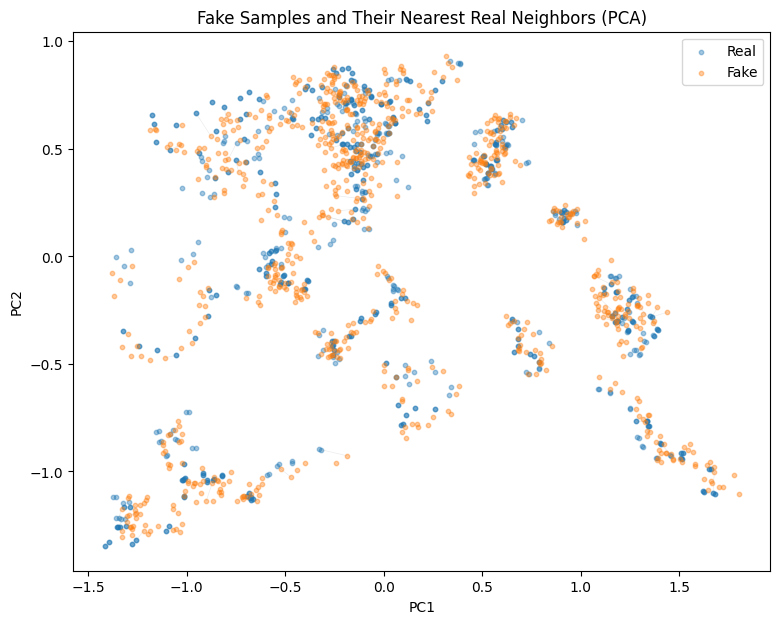

In [27]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_all = np.vstack([X_real, X_fake])
pca = PCA(n_components=2)
X_all_pca = pca.fit_transform(X_all)

X_real_pca = X_all_pca[:len(X_real)]
X_fake_pca = X_all_pca[len(X_real):]

plt.figure(figsize=(9,7))
plt.scatter(X_real_pca[:, 0], X_real_pca[:, 1], s=10, alpha=0.4, label="Real")
plt.scatter(X_fake_pca[:, 0], X_fake_pca[:, 1], s=10, alpha=0.4, label="Fake")

# draw lines for a small subset of fake points
subset = np.random.choice(len(X_fake), size=min(100, len(X_fake)), replace=False)

for i in subset:
    j = idx_fake_to_real[i, 0]
    plt.plot(
        [X_fake_pca[i, 0], X_real_pca[j, 0]],
        [X_fake_pca[i, 1], X_real_pca[j, 1]],
        color="gray",
        alpha=0.15,
        linewidth=0.5
    )

plt.title("Fake Samples and Their Nearest Real Neighbors (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

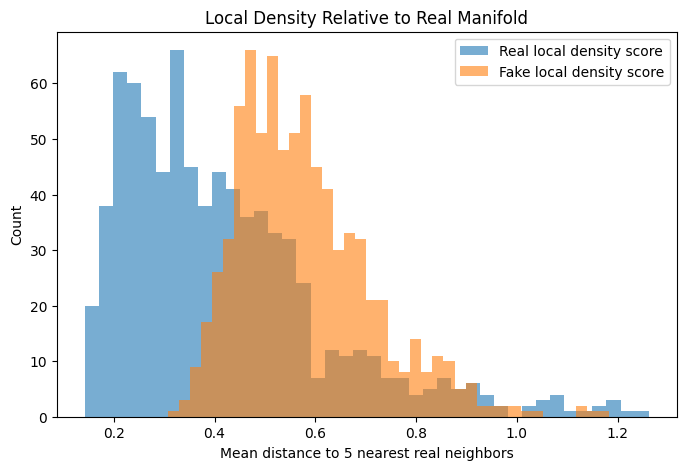

In [28]:
k = 5

nn_k = NearestNeighbors(n_neighbors=k, metric="euclidean")
nn_k.fit(X_real)

# fake to k nearest real
dist_fake_k, _ = nn_k.kneighbors(X_fake)
fake_density_score = dist_fake_k.mean(axis=1)

# real to k+1 nearest real (skip self)
nn_k_real = NearestNeighbors(n_neighbors=k+1, metric="euclidean")
nn_k_real.fit(X_real)
dist_real_k, _ = nn_k_real.kneighbors(X_real)
real_density_score = dist_real_k[:, 1:].mean(axis=1)

plt.figure(figsize=(8,5))
plt.hist(real_density_score, bins=40, alpha=0.6, label="Real local density score")
plt.hist(fake_density_score, bins=40, alpha=0.6, label="Fake local density score")
plt.xlabel(f"Mean distance to {k} nearest real neighbors")
plt.ylabel("Count")
plt.title("Local Density Relative to Real Manifold")
plt.legend()
plt.show()

In [32]:
threshold = np.percentile(real_baseline, 95)
outlier_fake_idx = np.where(fake_to_real > threshold)[0]

print("95th percentile real->real distance:", threshold)
print("Number of fake samples beyond this threshold:", len(outlier_fake_idx))

95th percentile real->real distance: 0.5189029183966812
Number of fake samples beyond this threshold: 224


In [60]:
import numpy as np
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"

# -----------------------------
# 1. Get top 25 most different features
# -----------------------------
top_k = 5
idx_sorted = np.argsort(np.abs(diff.values))[-top_k:]
top_features = [feature_cols[i] for i in idx_sorted]

print("Top 25 features:", top_features)

# -----------------------------
# 2. Use df_scaled (already standardized)
# -----------------------------
real_scaled = df_scaled[df_scaled["type"] == "real"].copy()
fake_scaled = df_scaled[df_scaled["type"] == "fake"].copy()

# Sample for clarity
n_real = min(100, len(real_scaled))
n_fake = min(100, len(fake_scaled))

df_plot = pd.concat(
    [
        real_scaled.sample(n=n_real, random_state=42),
        fake_scaled.sample(n=n_fake, random_state=42),
    ],
    ignore_index=True,
).copy()

# Add color code
df_plot["type_code"] = df_plot["type"].map({"real": 0, "fake": 1})

# -----------------------------
# 3. Parallel Coordinates Plot
# -----------------------------
fig = px.parallel_coordinates(
    df_plot,
    dimensions=top_features,
    color="type_code",
    color_continuous_scale=[(0.0, "blue"), (0.5, "blue"), (0.5, "red"), (1.0, "red")],
    range_color=(0, 1),
    labels={**{c: c for c in top_features}, "type_code": "Class"},
    title="Parallel Coordinates Plot (Top 25 Different Features)"
)

fig.update_layout(
    coloraxis_colorbar=dict(
        title="Type",
        tickvals=[0, 1],
        ticktext=["real", "fake"]
    )
)

fig.show()

Top 25 features: ['f126', 'f084', 'f108', 'f046', 'f052']


In [61]:
import re
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"

# -----------------------------
# 1. Load data
# -----------------------------
real = pd.read_csv(r"D:/KLAUS/Vis_Final_Project/real_feature_output/real_features.csv").copy()
fake = pd.read_csv(r"D:/KLAUS/Vis_Final_Project/fake_feature_output/fake_features.csv").copy()

real["type"] = "real"
fake["type"] = "fake"

df = pd.concat([real, fake], ignore_index=True).copy()

# -----------------------------
# 2. Keep only feature columns
# -----------------------------
feature_cols = [c for c in df.columns if re.fullmatch(r"f\d{3}", c)]

# -----------------------------
# 3. Standardize
# -----------------------------
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled.loc[:, feature_cols] = scaler.fit_transform(df_scaled[feature_cols])

# -----------------------------
# 4. Choose 5 features
#    example: 3 high-difference + 2 low-difference
# -----------------------------
selected_features = ["f126", "f084", "f108", "f003", "f010"]

# -----------------------------
# 5. Sample fewer rows
# -----------------------------
real_scaled = df_scaled[df_scaled["type"] == "real"].sample(n=20, random_state=42).copy()
fake_scaled = df_scaled[df_scaled["type"] == "fake"].sample(n=20, random_state=42).copy()

df_plot = pd.concat([real_scaled, fake_scaled], ignore_index=True).copy()
df_plot["type_code"] = df_plot["type"].map({"real": 0, "fake": 1})

# -----------------------------
# 6. PCP
# -----------------------------
fig = px.parallel_coordinates(
    df_plot,
    dimensions=selected_features,
    color="type_code",
    color_continuous_scale=[(0.0, "blue"), (0.5, "blue"), (0.5, "red"), (1.0, "red")],
    range_color=(0, 1),
    labels={**{c: c for c in selected_features}, "type_code": "Type"},
    title="Parallel Coordinates Plot (5 Selected Features)"
)

fig.update_layout(
    coloraxis_colorbar=dict(
        title="Type",
        tickvals=[0, 1],
        ticktext=["real", "fake"]
    )
)

fig.show()

In [17]:
import re
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "browser"

# -----------------------------
# 1. Load data
# -----------------------------
real = pd.read_csv(r"D:/KLAUS/Vis_Final_Project/real_feature_output/real_features.csv").copy()
fake = pd.read_csv(r"D:/KLAUS/Vis_Final_Project/fake_feature_output/fake_features.csv").copy()

real["type"] = "real"
fake["type"] = "fake"

df = pd.concat([real, fake], ignore_index=True).copy()

# -----------------------------
# 2. Feature columns
# -----------------------------
feature_cols = [c for c in df.columns if re.fullmatch(r"f\d{3}", c)]

# -----------------------------
# 3. Compute feature difference
# -----------------------------
real_mean = real[feature_cols].mean()
fake_mean = fake[feature_cols].mean()

diff = fake_mean - real_mean

# -----------------------------
# 4. Threshold-based selection
# -----------------------------
threshold = 0.01  # 🔥 YOU CAN CHANGE THIS

selected_features = diff[np.abs(diff) > threshold].index.tolist()

print("Selected features:", selected_features)
print("Number of selected features:", len(selected_features))

# -----------------------------
# SAFETY: if too many features
# -----------------------------
if len(selected_features) > 15:
    print("Too many features → taking top 15 only")
    idx_sorted = np.argsort(np.abs(diff.values))[-15:]
    selected_features = [feature_cols[i] for i in idx_sorted]

# -----------------------------
# 5. Standardize
# -----------------------------
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled.loc[:, feature_cols] = scaler.fit_transform(df_scaled[feature_cols])

# -----------------------------
# 6. Sample data
# -----------------------------
real_scaled = df_scaled[df_scaled["type"] == "real"].sample(n=20, random_state=42).copy()
fake_scaled = df_scaled[df_scaled["type"] == "fake"].sample(n=20, random_state=42).copy()

df_plot = pd.concat([real_scaled, fake_scaled], ignore_index=True).copy()
df_plot["type_code"] = df_plot["type"].map({"real": 0, "fake": 1})

# -----------------------------
# 7. PCP Plot
# -----------------------------
fig = px.parallel_coordinates(
    df_plot,
    dimensions=selected_features,
    color="type_code",
    color_continuous_scale=[(0.0, "blue"), (0.5, "blue"), (0.5, "red"), (1.0, "red")],
    range_color=(0, 1),
    labels={**{c: c for c in selected_features}, "type_code": "Type"},
    title=f"Parallel Coordinates (Features with |diff| > {threshold})"
)

fig.update_layout(
    coloraxis_colorbar=dict(
        title="Type",
        tickvals=[0, 1],
        ticktext=["real", "fake"]
    )
)

fig.show()

Selected features: ['f005', 'f009', 'f019', 'f039', 'f046', 'f052', 'f061', 'f081', 'f084', 'f095', 'f105', 'f108', 'f109', 'f122', 'f124', 'f126']
Number of selected features: 16
Too many features → taking top 15 only


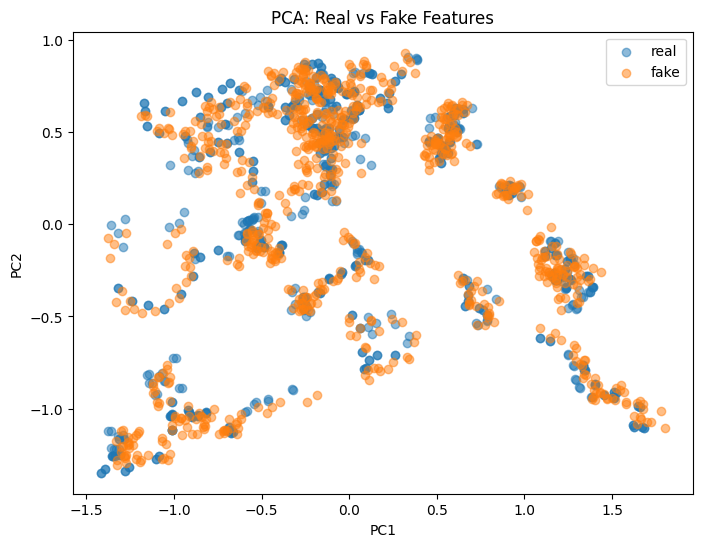

In [18]:
# 2D PCA

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8,6))

for label in ["real", "fake"]:
    idx = (y == label)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.5)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: Real vs Fake Features")
plt.legend()
plt.show()

Total samples: 1584
Total features: 128
Shape of X: (1584, 128)
Explained variance by PC1 and PC2: [0.18155593 0.12086136]
Total variance captured by 2 PCs: 0.30241728686747016

Cluster-wise composition:

Cluster 0  --> Assigned label: real
type
real    99
fake    98
Name: count, dtype: int64

Cluster 1  --> Assigned label: real
type
real    144
fake    144
Name: count, dtype: int64

Cluster 2  --> Assigned label: fake
type
fake    103
real    102
Name: count, dtype: int64

Cluster 3  --> Assigned label: real
type
real    238
fake    236
Name: count, dtype: int64

Cluster 4  --> Assigned label: fake
type
fake    86
real    82
Name: count, dtype: int64

Cluster 5  --> Assigned label: real
type
real    127
fake    125
Name: count, dtype: int64


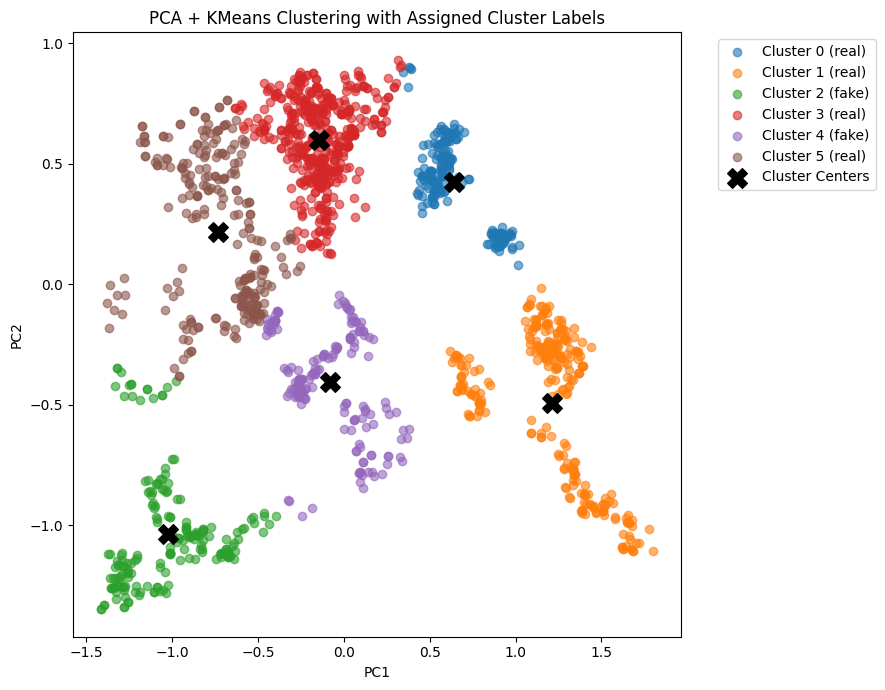

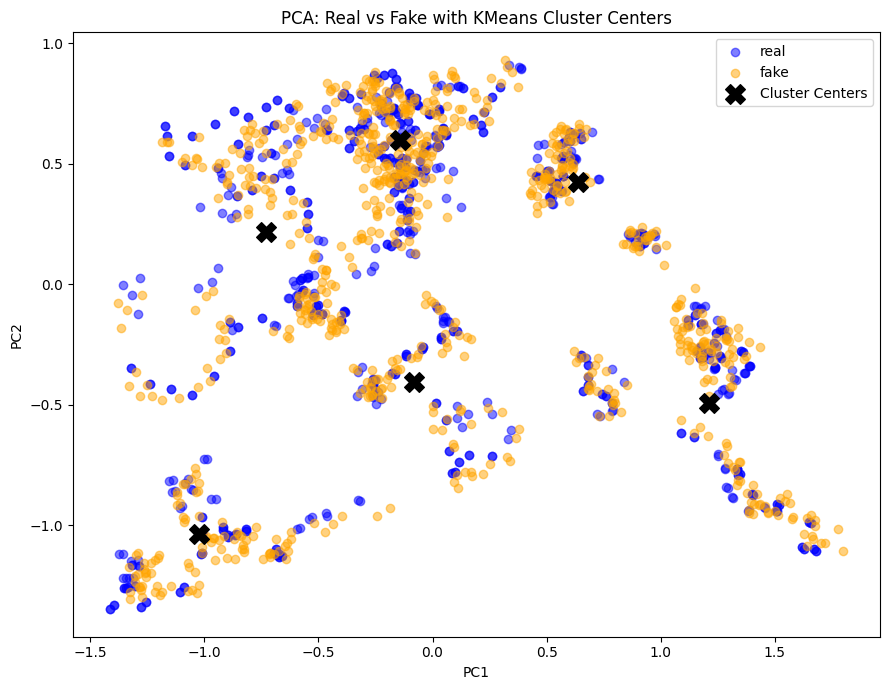

In [19]:
# ================================
# PCA + KMeans Clustering + Cluster Label Assignment
# ================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# -----------------------------
# 1. Load data
# -----------------------------
real = pd.read_csv(r"D:/KLAUS/Vis_Final_Project/real_feature_output/real_features.csv").copy()
fake = pd.read_csv(r"D:/KLAUS/Vis_Final_Project/fake_feature_output/fake_features.csv").copy()

# -----------------------------
# 2. Add class label
# -----------------------------
real["type"] = "real"
fake["type"] = "fake"

# -----------------------------
# 3. Combine
# -----------------------------
df = pd.concat([real, fake], ignore_index=True).copy()

# -----------------------------
# 4. Keep only true feature columns
# -----------------------------
feature_cols = [c for c in df.columns if re.fullmatch(r"f\d{3}", c)]

# Feature matrix and class labels
X = df[feature_cols].to_numpy(dtype=float)
y = df["type"].to_numpy()

print("Total samples:", len(df))
print("Total features:", len(feature_cols))
print("Shape of X:", X.shape)

# -----------------------------
# 5. PCA (2D)
# -----------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print("Explained variance by PC1 and PC2:", pca.explained_variance_ratio_)
print("Total variance captured by 2 PCs:", pca.explained_variance_ratio_.sum())

# -----------------------------
# 6. KMeans clustering
# -----------------------------
k = 6  # change if needed
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# -----------------------------
# 7. Build cluster dataframe
# -----------------------------
df_cluster = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "type": y,
    "cluster": clusters
})

# -----------------------------
# 8. Assign majority class label to each cluster
# -----------------------------
cluster_labels = {}

for c in range(k):
    subset = df_cluster[df_cluster["cluster"] == c]
    counts = subset["type"].value_counts()

    if len(counts) > 0:
        cluster_labels[c] = counts.idxmax()
    else:
        cluster_labels[c] = "unknown"

df_cluster["cluster_label"] = df_cluster["cluster"].map(cluster_labels)

# -----------------------------
# 9. Print cluster composition
# -----------------------------
print("\nCluster-wise composition:")
for c in range(k):
    subset = df_cluster[df_cluster["cluster"] == c]
    print(f"\nCluster {c}  --> Assigned label: {cluster_labels[c]}")
    print(subset["type"].value_counts())

# -----------------------------
# 10. Plot PCA with cluster colors
# -----------------------------
plt.figure(figsize=(9, 7))

for c in range(k):
    subset = df_cluster[df_cluster["cluster"] == c]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.6,
        label=f"Cluster {c} ({cluster_labels[c]})"
    )

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="black",
    s=200,
    marker="X",
    label="Cluster Centers"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA + KMeans Clustering with Assigned Cluster Labels")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# -----------------------------
# 11. Plot real vs fake with cluster centers
# -----------------------------
plt.figure(figsize=(9, 7))

for label, color in zip(["real", "fake"], ["blue", "orange"]):
    idx = (df_cluster["type"] == label)
    plt.scatter(
        df_cluster.loc[idx, "PC1"],
        df_cluster.loc[idx, "PC2"],
        c=color,
        alpha=0.5,
        label=label
    )

plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="black",
    s=200,
    marker="X",
    label="Cluster Centers"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: Real vs Fake with KMeans Cluster Centers")
plt.legend()
plt.tight_layout()
plt.show()

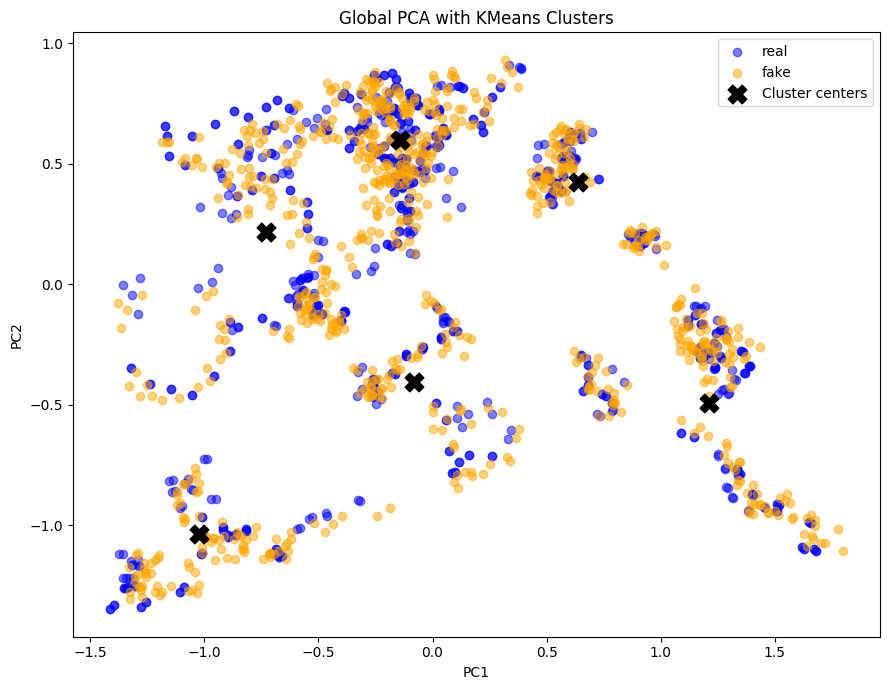

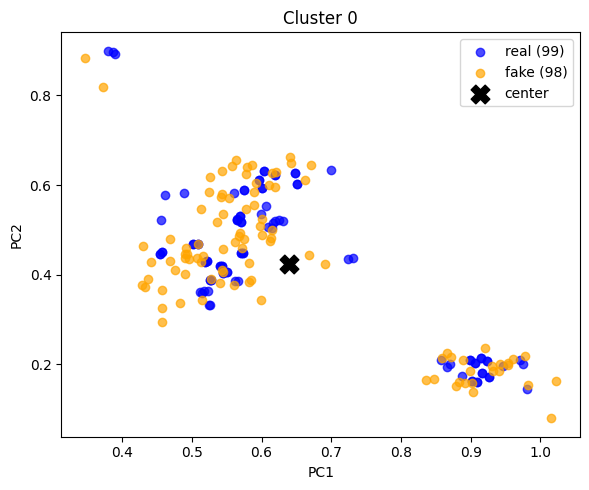


Cluster 0 composition:
type
real    99
fake    98
Name: count, dtype: int64


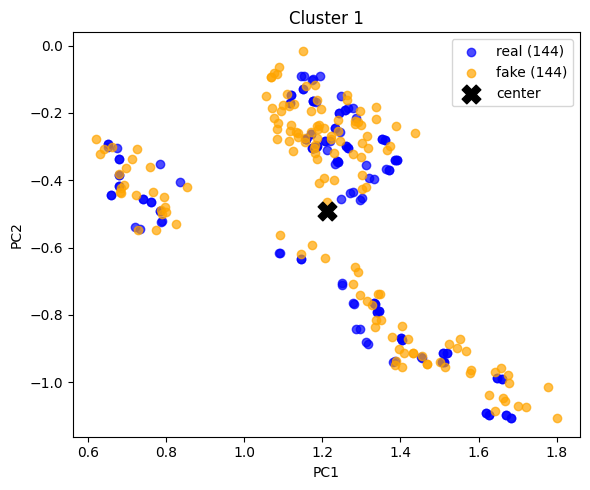


Cluster 1 composition:
type
real    144
fake    144
Name: count, dtype: int64


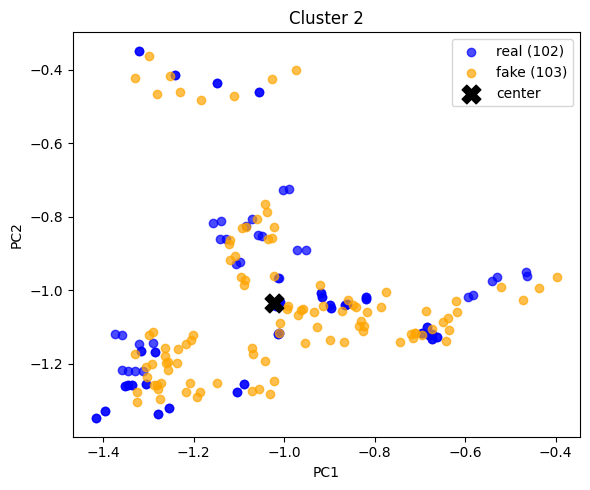


Cluster 2 composition:
type
fake    103
real    102
Name: count, dtype: int64


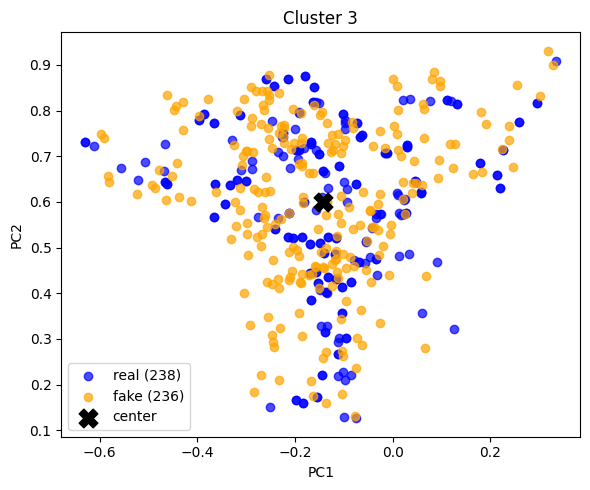


Cluster 3 composition:
type
real    238
fake    236
Name: count, dtype: int64


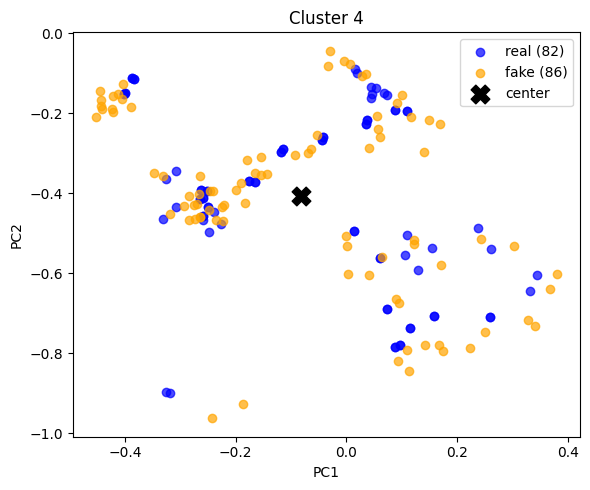


Cluster 4 composition:
type
fake    86
real    82
Name: count, dtype: int64


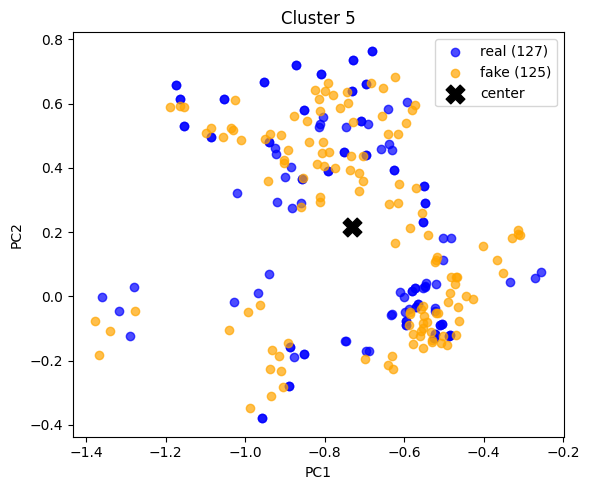


Cluster 5 composition:
type
real    127
fake    125
Name: count, dtype: int64


In [20]:
# ==========================================
# PCA + KMeans + Separate plot for each cluster
# keeping real/fake color coding the same
# ==========================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# -----------------------------
# 1. Load data
# -----------------------------
real = pd.read_csv(r"D:/KLAUS/Vis_Final_Project/real_feature_output/real_features.csv").copy()
fake = pd.read_csv(r"D:/KLAUS/Vis_Final_Project/fake_feature_output/fake_features.csv").copy()

# -----------------------------
# 2. Add labels
# -----------------------------
real["type"] = "real"
fake["type"] = "fake"

# -----------------------------
# 3. Combine data
# -----------------------------
df = pd.concat([real, fake], ignore_index=True).copy()

# -----------------------------
# 4. Keep only feature columns
# -----------------------------
feature_cols = [c for c in df.columns if re.fullmatch(r"f\d{3}", c)]

X = df[feature_cols].to_numpy(dtype=float)
y = df["type"].to_numpy()

# -----------------------------
# 5. PCA to 2D
# -----------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# -----------------------------
# 6. KMeans clustering on PCA points
# -----------------------------
k = 6   # change this if needed
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)

# -----------------------------
# 7. Build dataframe
# -----------------------------
df_cluster = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "type": y,
    "cluster": clusters
})

# -----------------------------
# 8. Global PCA plot with clusters
# -----------------------------
plt.figure(figsize=(9, 7))

for label, color in zip(["real", "fake"], ["blue", "orange"]):
    idx = (df_cluster["type"] == label)
    plt.scatter(
        df_cluster.loc[idx, "PC1"],
        df_cluster.loc[idx, "PC2"],
        c=color,
        alpha=0.5,
        label=label
    )

centers = kmeans.cluster_centers_
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c="black",
    s=180,
    marker="X",
    label="Cluster centers"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Global PCA with KMeans Clusters")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 9. Separate plot for each cluster
# -----------------------------
for c in range(k):
    subset = df_cluster[df_cluster["cluster"] == c]

    plt.figure(figsize=(6, 5))

    # plot only points from this cluster
    for label, color in zip(["real", "fake"], ["blue", "orange"]):
        sub_label = subset[subset["type"] == label]
        plt.scatter(
            sub_label["PC1"],
            sub_label["PC2"],
            c=color,
            alpha=0.7,
            label=f"{label} ({len(sub_label)})"
        )

    # cluster center
    plt.scatter(
        centers[c, 0],
        centers[c, 1],
        c="black",
        s=180,
        marker="X",
        label="center"
    )

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"Cluster {c}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # print composition
    print(f"\nCluster {c} composition:")
    print(subset["type"].value_counts())

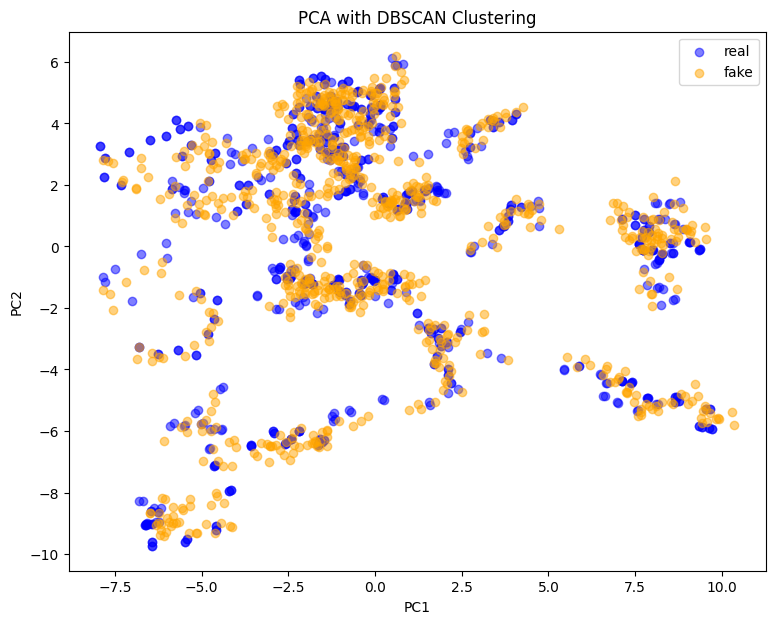

Clusters found: [-1  0  1  2  3  4  5  6  7  8  9 10 11 12]


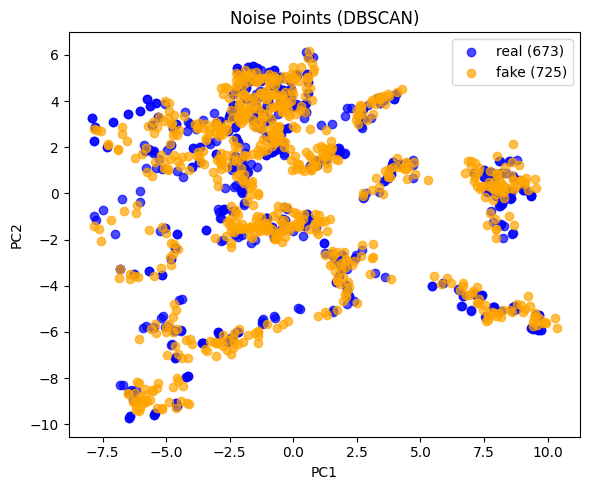


Cluster -1 composition:
type
fake    725
real    673
Name: count, dtype: int64


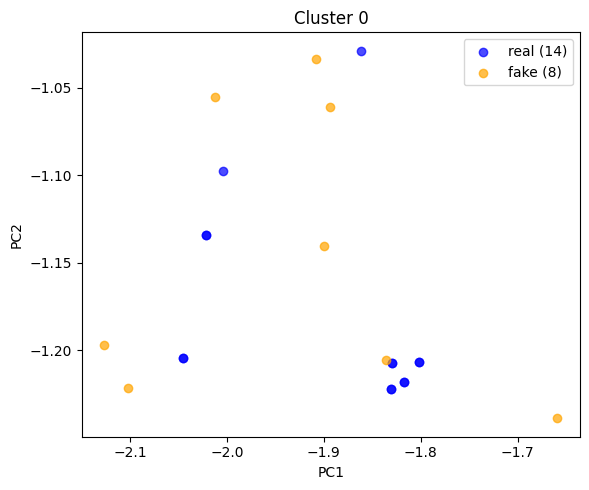


Cluster 0 composition:
type
real    14
fake     8
Name: count, dtype: int64


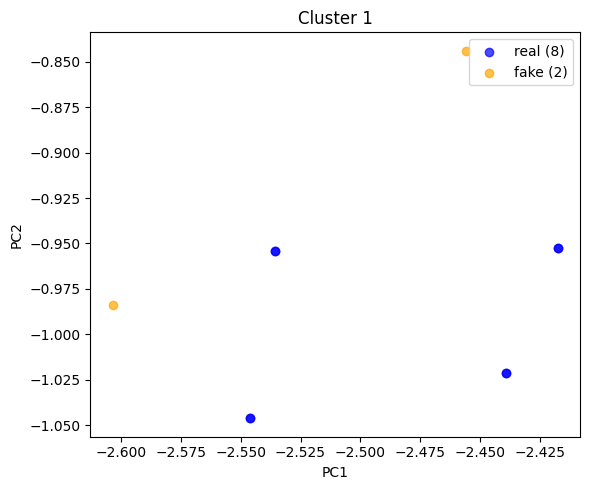


Cluster 1 composition:
type
real    8
fake    2
Name: count, dtype: int64


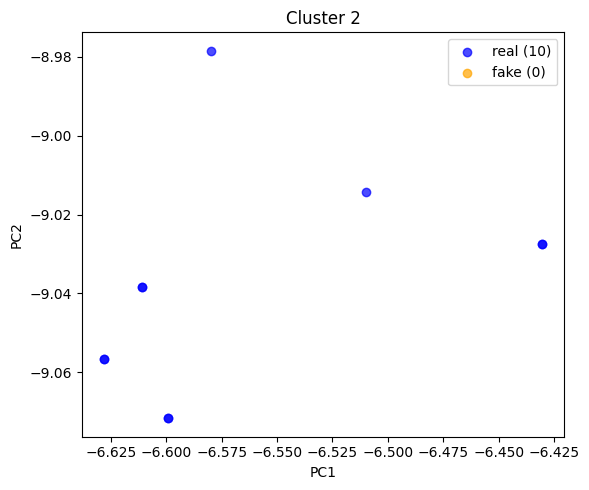


Cluster 2 composition:
type
real    10
Name: count, dtype: int64


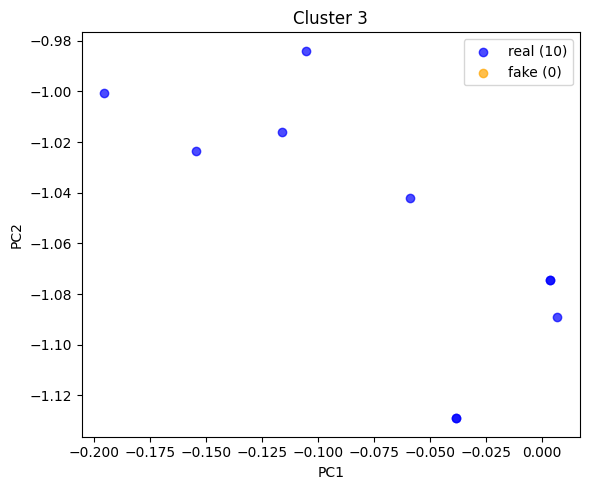


Cluster 3 composition:
type
real    10
Name: count, dtype: int64


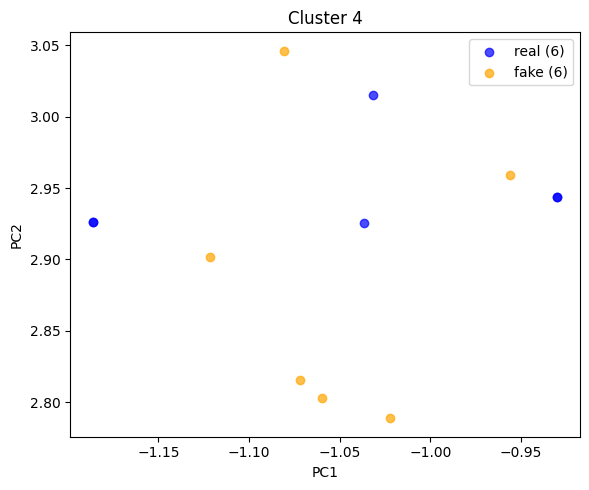


Cluster 4 composition:
type
real    6
fake    6
Name: count, dtype: int64


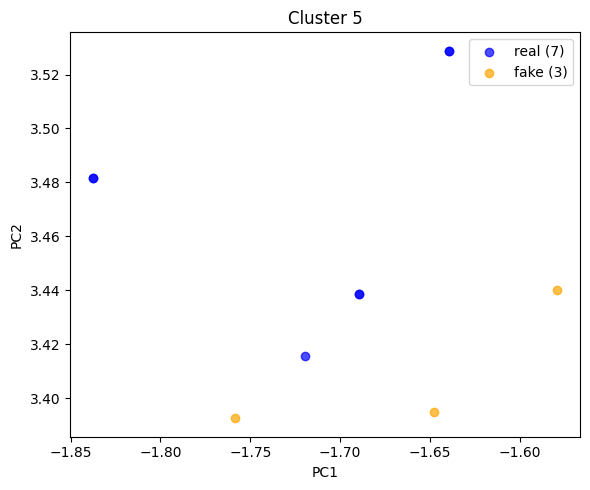


Cluster 5 composition:
type
real    7
fake    3
Name: count, dtype: int64


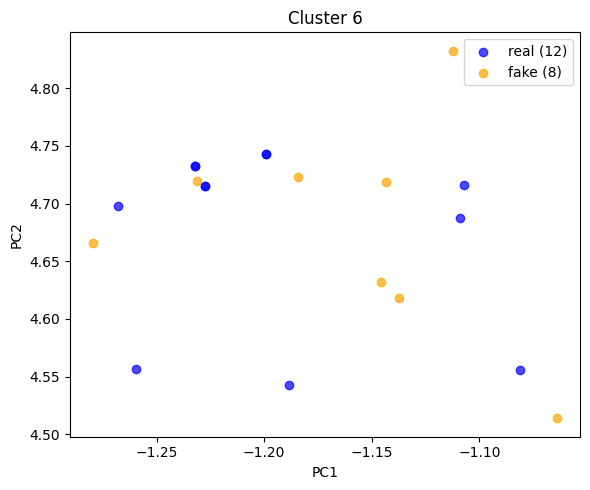


Cluster 6 composition:
type
real    12
fake     8
Name: count, dtype: int64


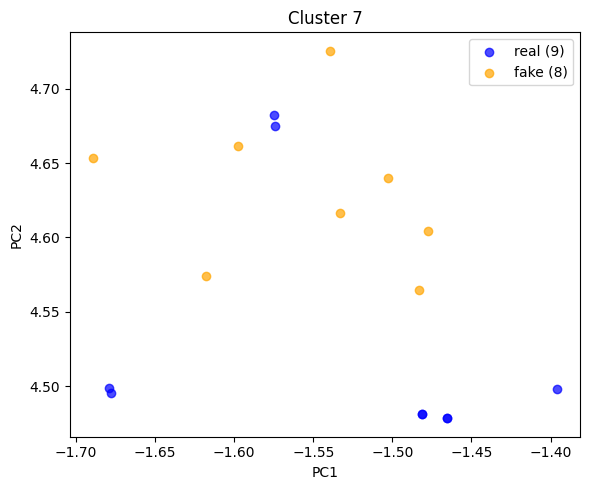


Cluster 7 composition:
type
real    9
fake    8
Name: count, dtype: int64


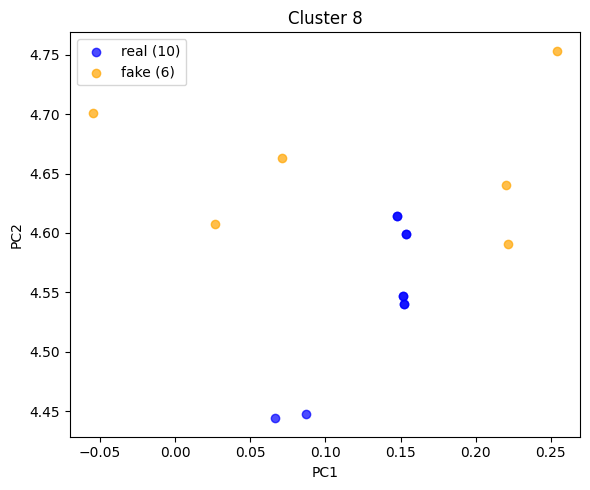


Cluster 8 composition:
type
real    10
fake     6
Name: count, dtype: int64


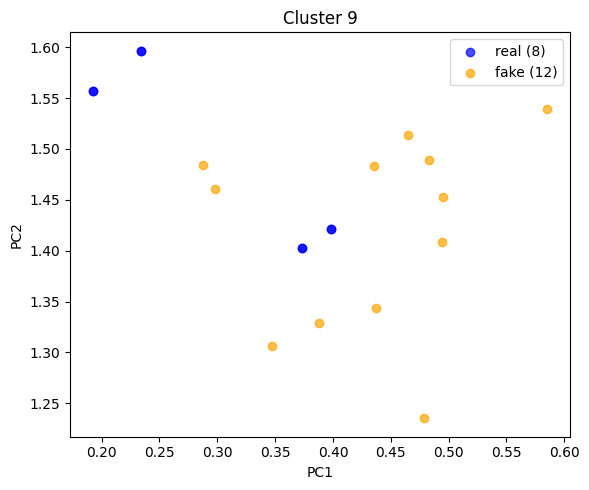


Cluster 9 composition:
type
fake    12
real     8
Name: count, dtype: int64


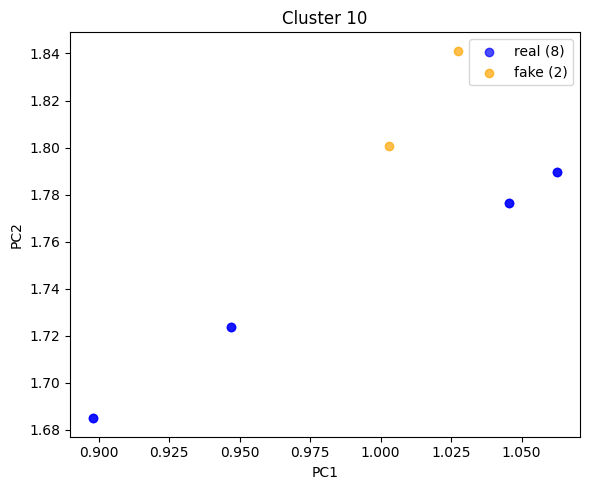


Cluster 10 composition:
type
real    8
fake    2
Name: count, dtype: int64


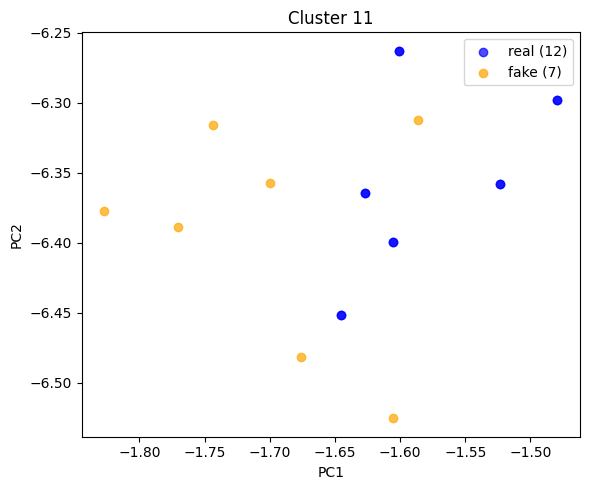


Cluster 11 composition:
type
real    12
fake     7
Name: count, dtype: int64


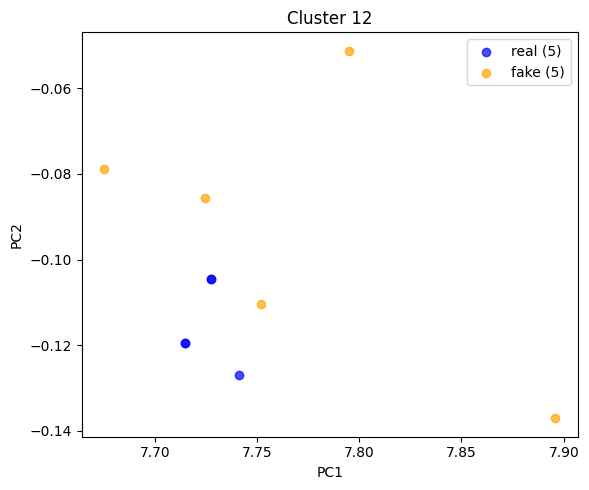


Cluster 12 composition:
type
real    5
fake    5
Name: count, dtype: int64


In [21]:
# ==========================================
# PCA + DBSCAN + Separate cluster plots
# ==========================================

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Load data
# -----------------------------
real = pd.read_csv(r"D:/KLAUS/Vis_Final_Project/real_feature_output/real_features.csv").copy()
fake = pd.read_csv(r"D:/KLAUS/Vis_Final_Project/fake_feature_output/fake_features.csv").copy()

real["type"] = "real"
fake["type"] = "fake"

df = pd.concat([real, fake], ignore_index=True).copy()

# -----------------------------
# 2. Feature columns
# -----------------------------
feature_cols = [c for c in df.columns if re.fullmatch(r"f\d{3}", c)]

# Standardize BEFORE PCA (important for DBSCAN)
scaler = StandardScaler()
X = scaler.fit_transform(df[feature_cols])

y = df["type"].values

# -----------------------------
# 3. PCA
# -----------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# -----------------------------
# 4. DBSCAN
# -----------------------------
# 🔥 Tune these parameters
dbscan = DBSCAN(eps=0.15, min_samples=10)
clusters = dbscan.fit_predict(X_pca)

# -----------------------------
# 5. Build dataframe
# -----------------------------
df_cluster = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "type": y,
    "cluster": clusters
})

# -----------------------------
# 6. Global plot
# -----------------------------
plt.figure(figsize=(9,7))

for label, color in zip(["real", "fake"], ["blue", "orange"]):
    subset = df_cluster[df_cluster["type"] == label]
    plt.scatter(subset["PC1"], subset["PC2"], c=color, alpha=0.5, label=label)

plt.title("PCA with DBSCAN Clustering")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

# -----------------------------
# 7. Unique clusters
# -----------------------------
unique_clusters = np.unique(clusters)

print("Clusters found:", unique_clusters)

# -----------------------------
# 8. Separate plots per cluster
# -----------------------------
for c in unique_clusters:
    subset = df_cluster[df_cluster["cluster"] == c]

    plt.figure(figsize=(6,5))

    for label, color in zip(["real", "fake"], ["blue", "orange"]):
        sub_label = subset[subset["type"] == label]
        plt.scatter(
            sub_label["PC1"],
            sub_label["PC2"],
            c=color,
            alpha=0.7,
            label=f"{label} ({len(sub_label)})"
        )

    if c == -1:
        plt.title("Noise Points (DBSCAN)")
    else:
        plt.title(f"Cluster {c}")

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    print(f"\nCluster {c} composition:")
    print(subset["type"].value_counts())

In [22]:
# already done
X_pca = PCA(n_components=2).fit_transform(X)

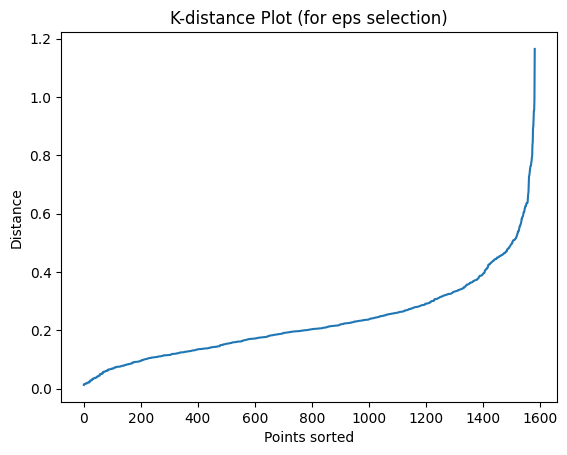

In [23]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_pca)

distances, indices = neighbors_fit.kneighbors(X_pca)

# sort distances
distances = np.sort(distances[:, 4])

plt.plot(distances)
plt.title("K-distance Plot (for eps selection)")
plt.xlabel("Points sorted")
plt.ylabel("Distance")
plt.show()

In [46]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.65, min_samples=5)  # tune eps!
clusters = dbscan.fit_predict(X_pca)

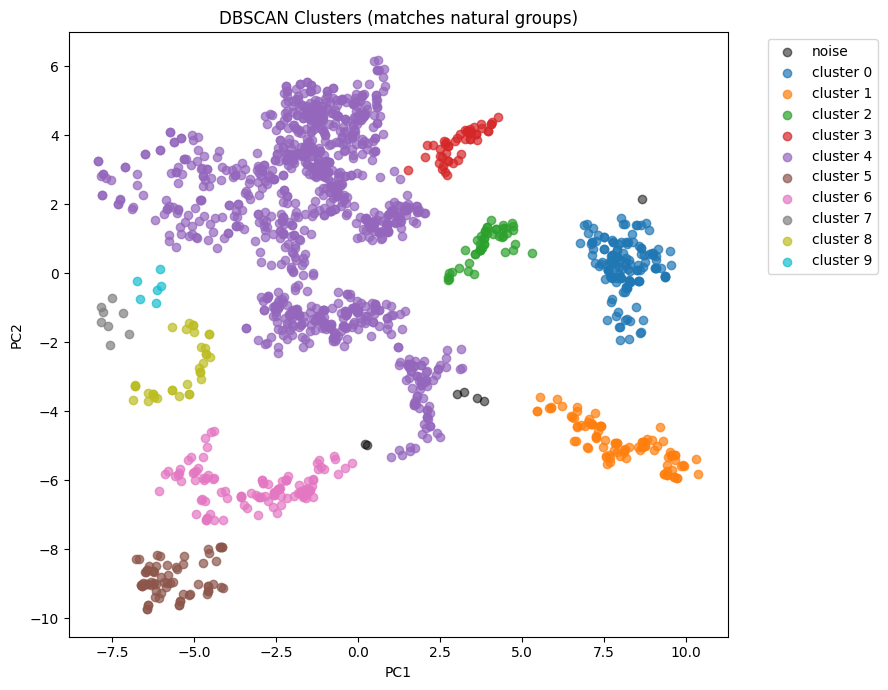

In [47]:
plt.figure(figsize=(9,7))

unique_clusters = np.unique(clusters)

for c in unique_clusters:
    subset = X_pca[clusters == c]
    
    if c == -1:
        plt.scatter(subset[:,0], subset[:,1], c='black', label='noise', alpha=0.5)
    else:
        plt.scatter(subset[:,0], subset[:,1], label=f'cluster {c}', alpha=0.7)

plt.title("DBSCAN Clusters (matches natural groups)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(bbox_to_anchor=(1.05,1))
plt.tight_layout()
plt.show()

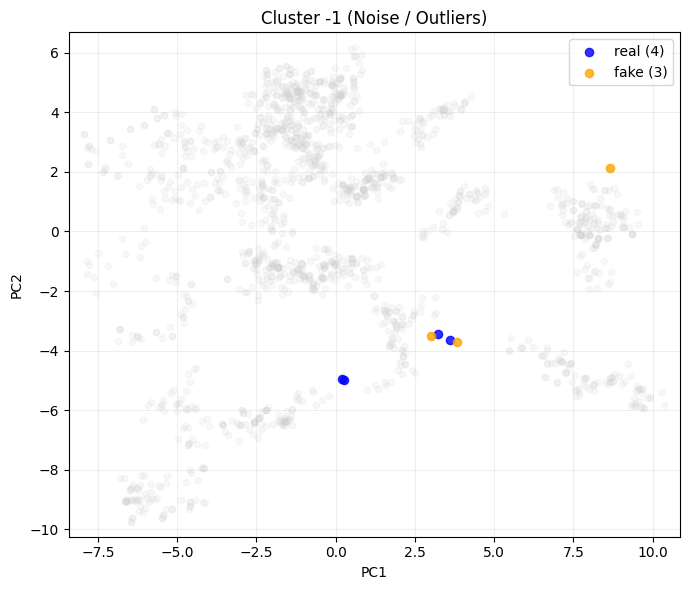


Cluster -1 composition:
type
real    4
fake    3
Name: count, dtype: int64


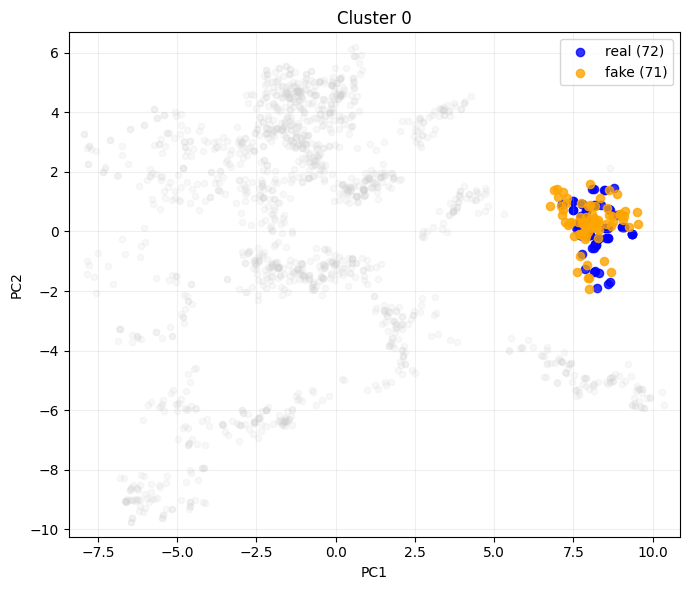


Cluster 0 composition:
type
real    72
fake    71
Name: count, dtype: int64


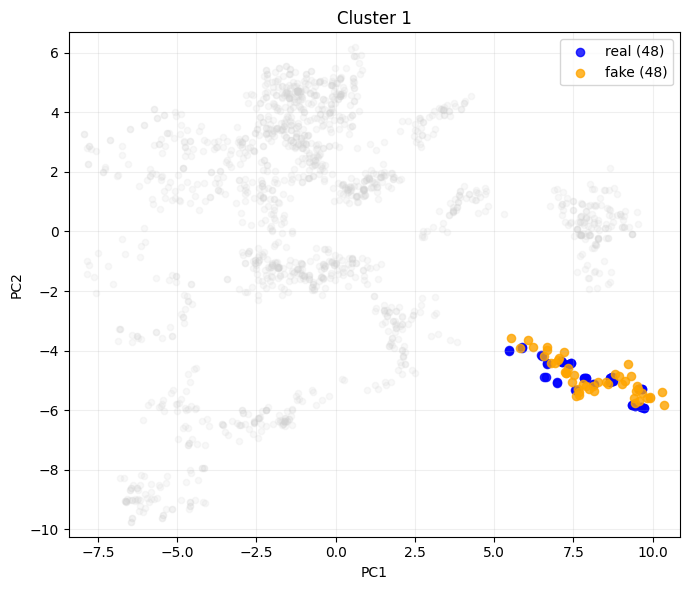


Cluster 1 composition:
type
real    48
fake    48
Name: count, dtype: int64


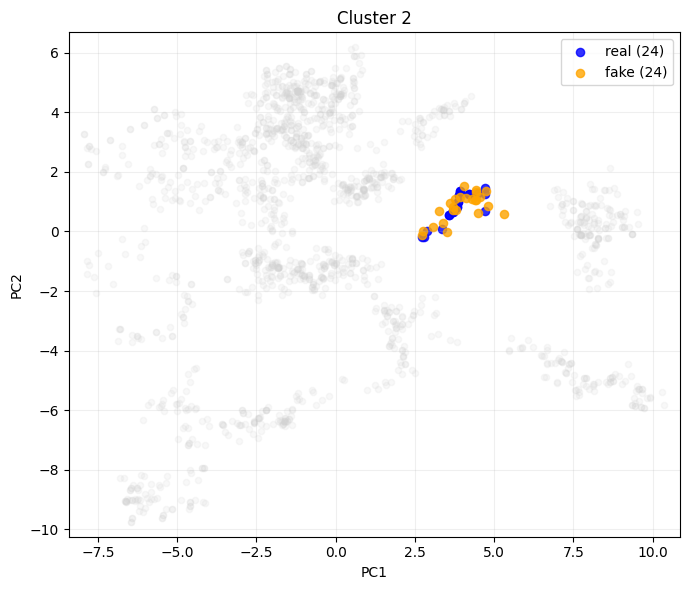


Cluster 2 composition:
type
real    24
fake    24
Name: count, dtype: int64


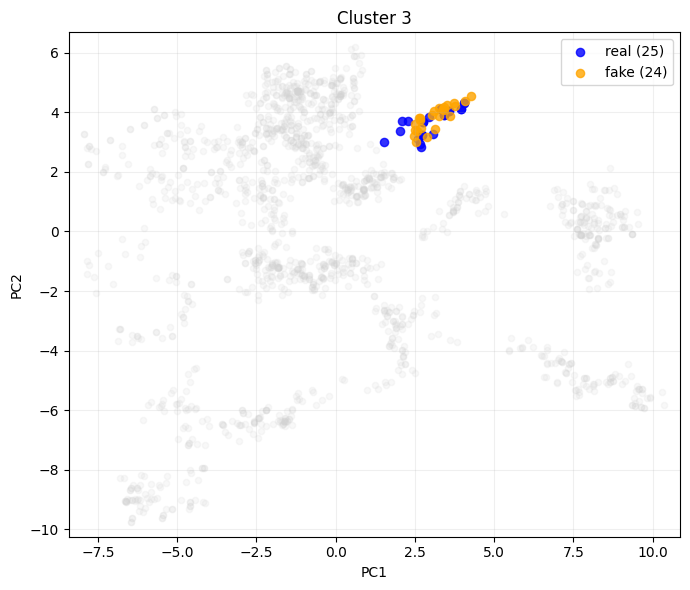


Cluster 3 composition:
type
real    25
fake    24
Name: count, dtype: int64


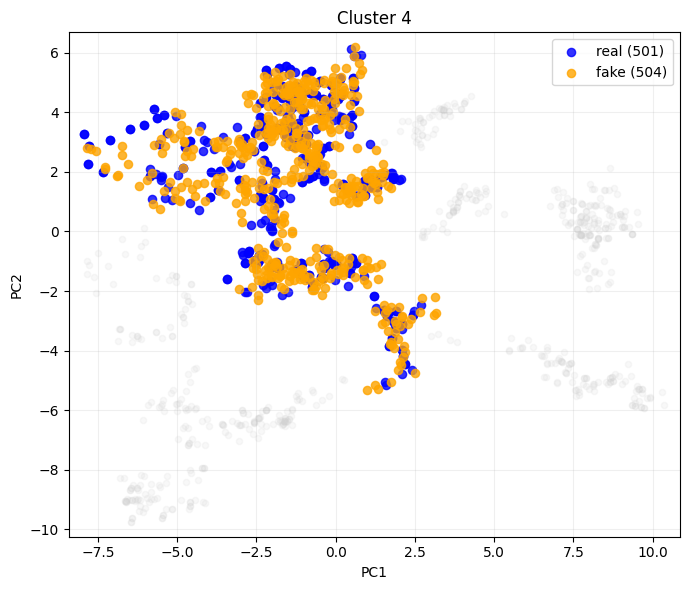


Cluster 4 composition:
type
fake    504
real    501
Name: count, dtype: int64


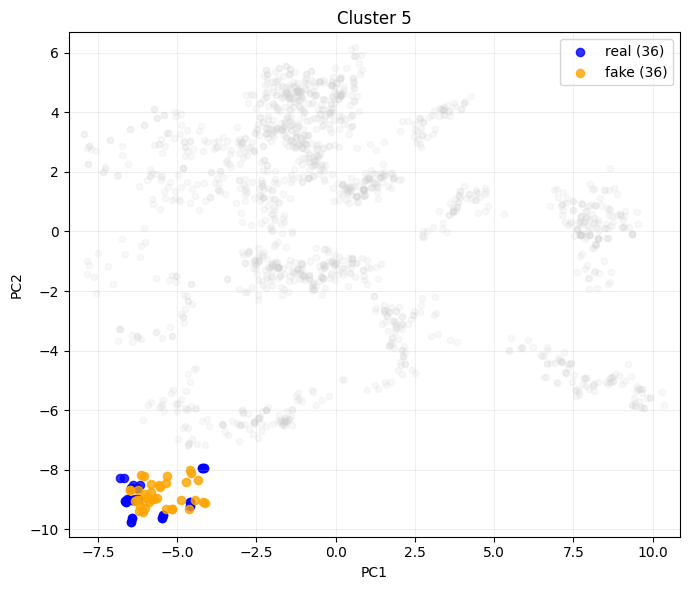


Cluster 5 composition:
type
real    36
fake    36
Name: count, dtype: int64


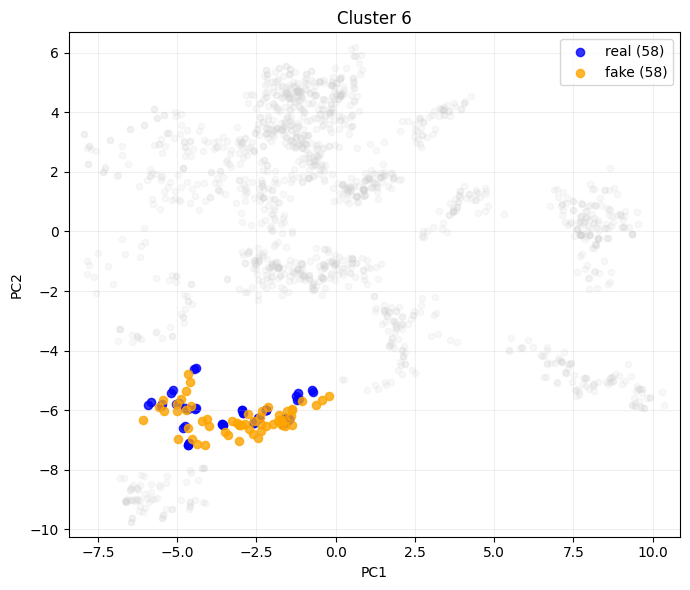


Cluster 6 composition:
type
real    58
fake    58
Name: count, dtype: int64


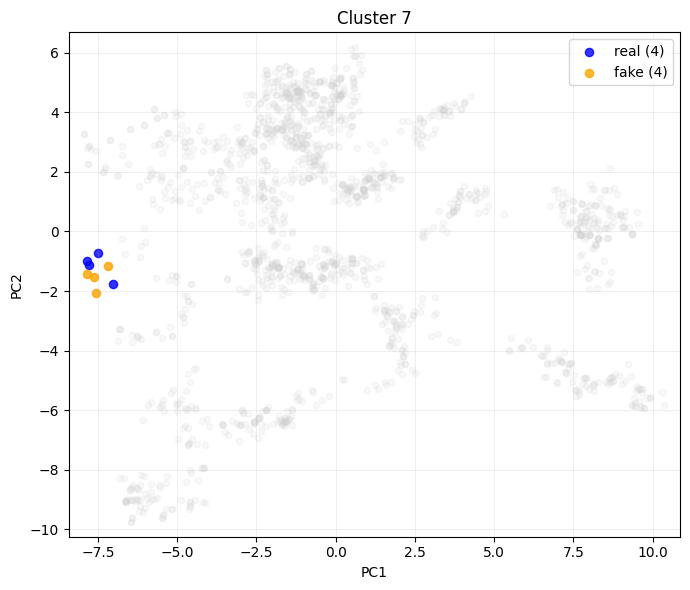


Cluster 7 composition:
type
real    4
fake    4
Name: count, dtype: int64


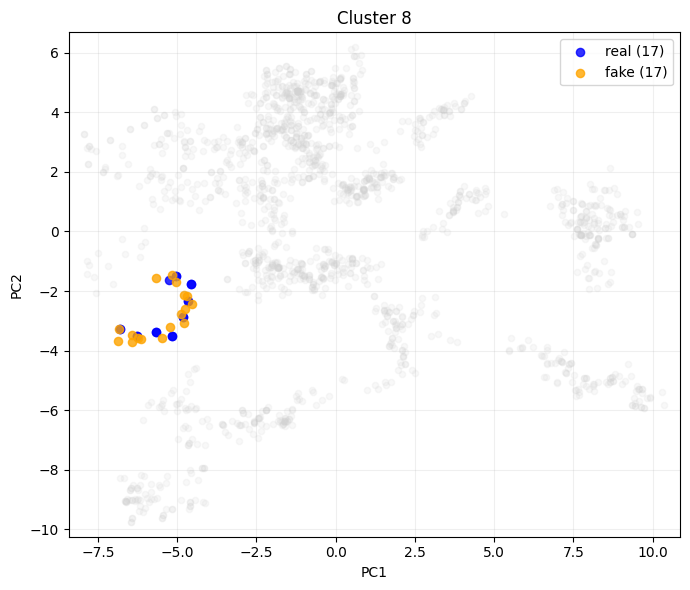


Cluster 8 composition:
type
real    17
fake    17
Name: count, dtype: int64


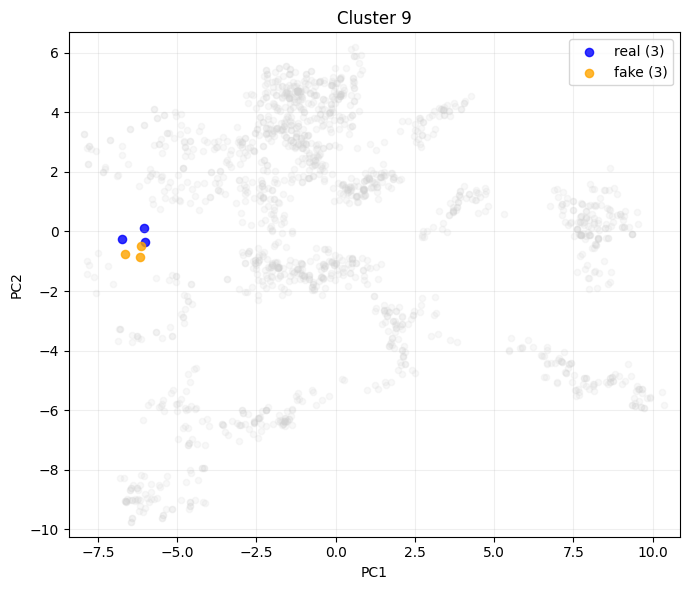


Cluster 9 composition:
type
real    3
fake    3
Name: count, dtype: int64


In [49]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Dataframe with PCA coordinates + labels + clusters
df_cluster = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "type": y,
    "cluster": clusters
})

unique_clusters = sorted(df_cluster["cluster"].unique())

# Global axis limits from full PCA plot
x_min, x_max = X_pca[:, 0].min(), X_pca[:, 0].max()
y_min, y_max = X_pca[:, 1].min(), X_pca[:, 1].max()

for c in unique_clusters:
    subset = df_cluster[df_cluster["cluster"] == c]

    plt.figure(figsize=(7, 6))

    # optional: show all points faintly in background
    plt.scatter(
        df_cluster["PC1"], df_cluster["PC2"],
        c="lightgray", alpha=0.15, s=20
    )

    # real and fake points of only this cluster
    real_points = subset[subset["type"] == "real"]
    fake_points = subset[subset["type"] == "fake"]

    plt.scatter(
        real_points["PC1"], real_points["PC2"],
        c="blue", alpha=0.8, s=35, label=f"real ({len(real_points)})"
    )
    plt.scatter(
        fake_points["PC1"], fake_points["PC2"],
        c="orange", alpha=0.8, s=35, label=f"fake ({len(fake_points)})"
    )

    # keep SAME positioning as full plot
    plt.xlim(x_min - 0.5, x_max + 0.5)
    plt.ylim(y_min - 0.5, y_max + 0.5)

    if c == -1:
        plt.title("Cluster -1 (Noise / Outliers)")
    else:
        plt.title(f"Cluster {c}")

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

    print(f"\nCluster {c} composition:")
    print(subset["type"].value_counts())

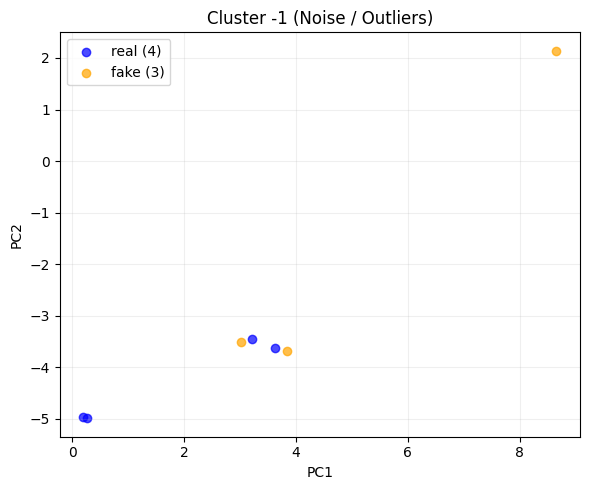


Cluster -1 composition:
type
real    4
fake    3
Name: count, dtype: int64


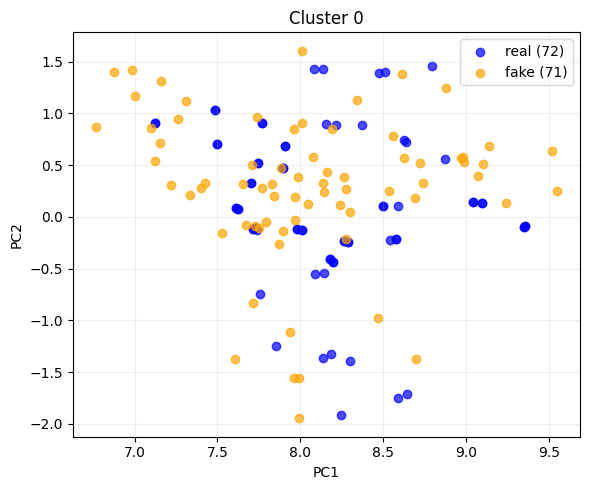


Cluster 0 composition:
type
real    72
fake    71
Name: count, dtype: int64


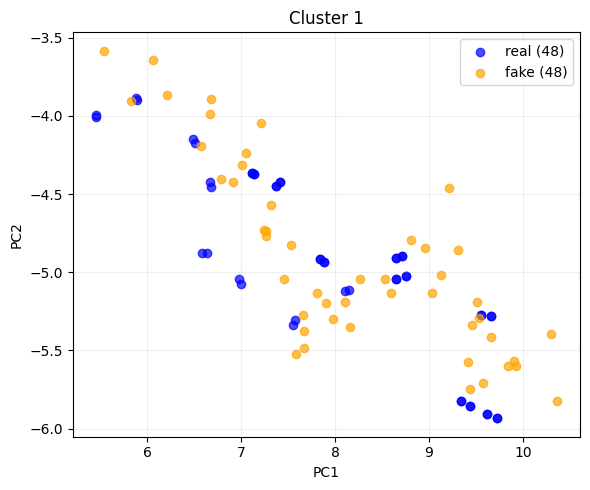


Cluster 1 composition:
type
real    48
fake    48
Name: count, dtype: int64


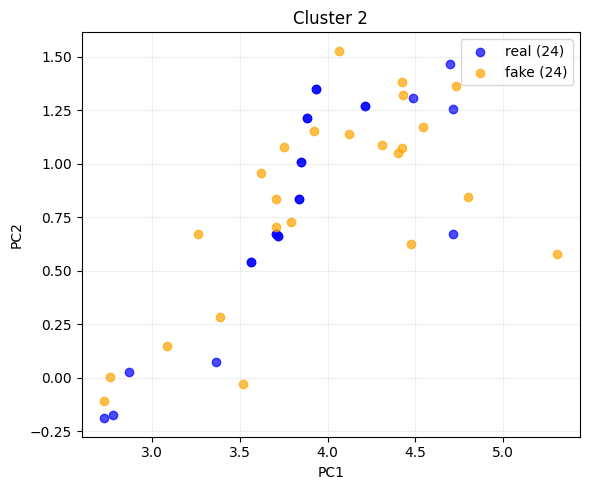


Cluster 2 composition:
type
real    24
fake    24
Name: count, dtype: int64


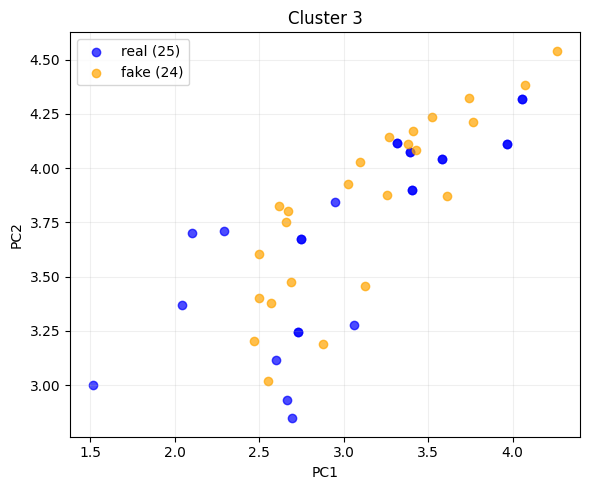


Cluster 3 composition:
type
real    25
fake    24
Name: count, dtype: int64


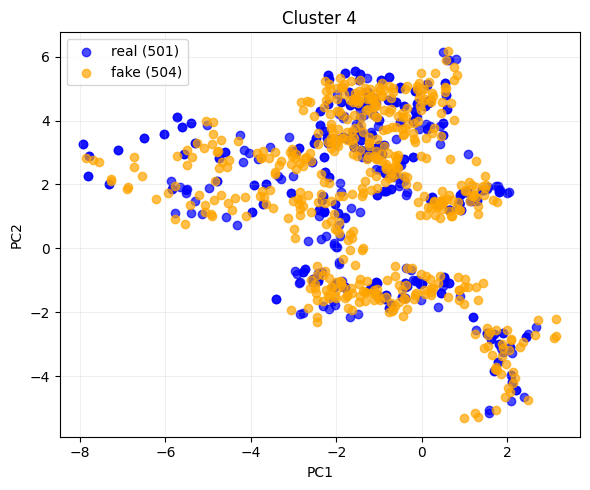


Cluster 4 composition:
type
fake    504
real    501
Name: count, dtype: int64


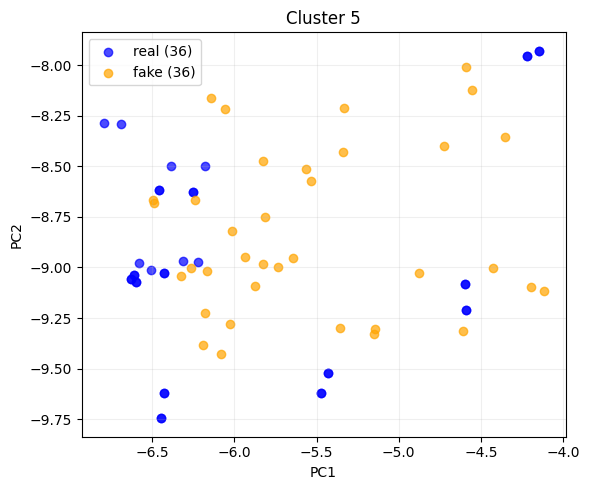


Cluster 5 composition:
type
real    36
fake    36
Name: count, dtype: int64


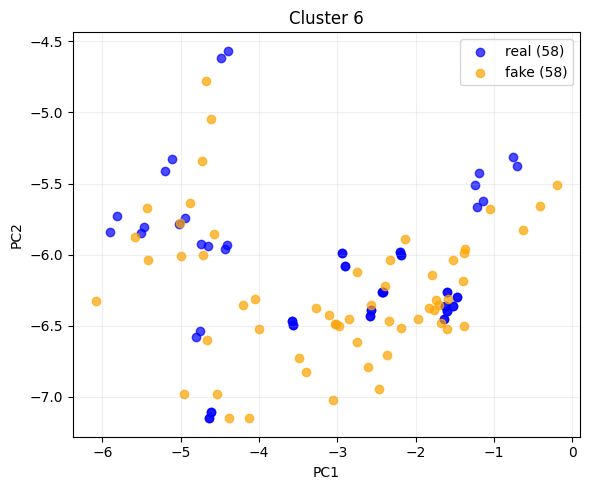


Cluster 6 composition:
type
real    58
fake    58
Name: count, dtype: int64


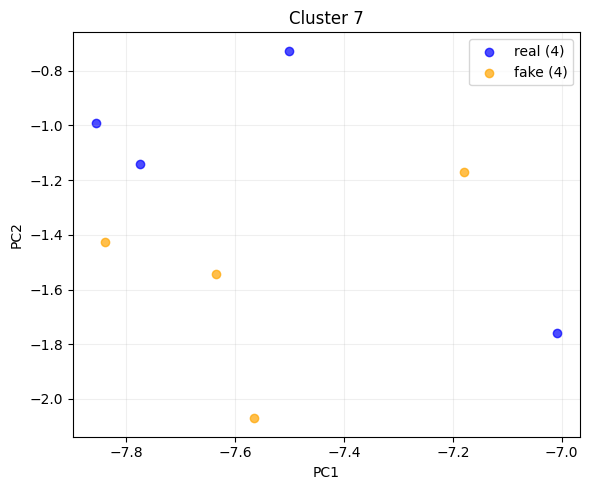


Cluster 7 composition:
type
real    4
fake    4
Name: count, dtype: int64


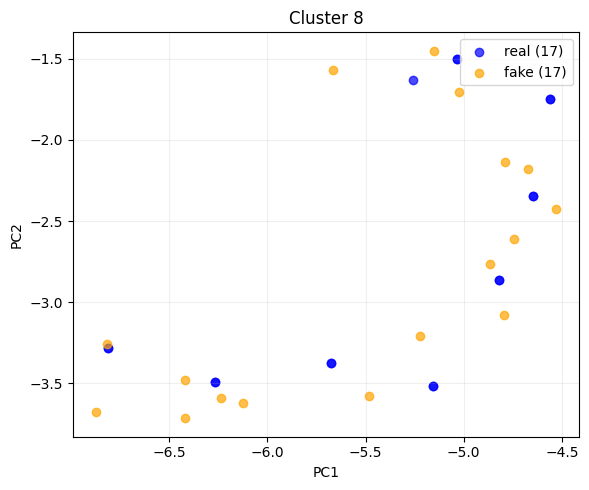


Cluster 8 composition:
type
real    17
fake    17
Name: count, dtype: int64


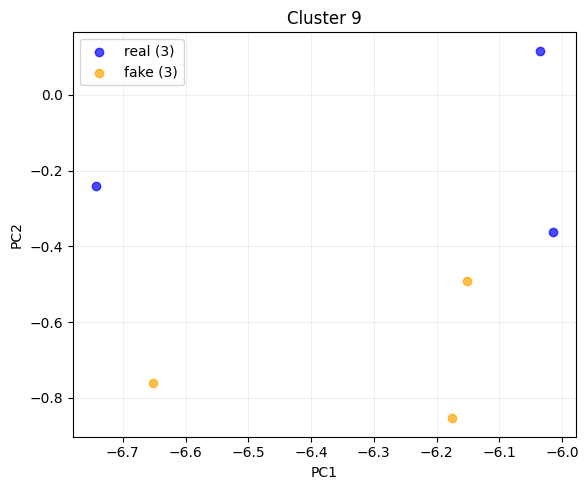


Cluster 9 composition:
type
real    3
fake    3
Name: count, dtype: int64


In [48]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Create dataframe with PCA + labels + clusters
df_cluster = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "type": y,
    "cluster": clusters
})

unique_clusters = sorted(df_cluster["cluster"].unique())

# Loop over clusters
for c in unique_clusters:

    subset = df_cluster[df_cluster["cluster"] == c]

    plt.figure(figsize=(6,5))

    # Plot real and fake separately
    real_points = subset[subset["type"] == "real"]
    fake_points = subset[subset["type"] == "fake"]

    plt.scatter(real_points["PC1"], real_points["PC2"],
                c="blue", alpha=0.7, label=f"real ({len(real_points)})")

    plt.scatter(fake_points["PC1"], fake_points["PC2"],
                c="orange", alpha=0.7, label=f"fake ({len(fake_points)})")

    # Title handling
    if c == -1:
        plt.title("Cluster -1 (Noise / Outliers)")
    else:
        plt.title(f"Cluster {c}")

    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

    # Print composition (VERY IMPORTANT)
    print(f"\nCluster {c} composition:")
    print(subset["type"].value_counts())

In [50]:
# Cluster Composition Analysis

df_cluster = pd.DataFrame({
    "cluster": clusters,
    "type": y
})

for c in sorted(df_cluster["cluster"].unique()):
    subset = df_cluster[df_cluster["cluster"] == c]
    
    total = len(subset)
    real_count = (subset["type"] == "real").sum()
    fake_count = (subset["type"] == "fake").sum()
    
    print(f"\nCluster {c}:")
    print(f"Total: {total}")
    print(f"Real: {real_count} ({real_count/total:.2f})")
    print(f"Fake: {fake_count} ({fake_count/total:.2f})")


Cluster -1:
Total: 7
Real: 4 (0.57)
Fake: 3 (0.43)

Cluster 0:
Total: 143
Real: 72 (0.50)
Fake: 71 (0.50)

Cluster 1:
Total: 96
Real: 48 (0.50)
Fake: 48 (0.50)

Cluster 2:
Total: 48
Real: 24 (0.50)
Fake: 24 (0.50)

Cluster 3:
Total: 49
Real: 25 (0.51)
Fake: 24 (0.49)

Cluster 4:
Total: 1005
Real: 501 (0.50)
Fake: 504 (0.50)

Cluster 5:
Total: 72
Real: 36 (0.50)
Fake: 36 (0.50)

Cluster 6:
Total: 116
Real: 58 (0.50)
Fake: 58 (0.50)

Cluster 7:
Total: 8
Real: 4 (0.50)
Fake: 4 (0.50)

Cluster 8:
Total: 34
Real: 17 (0.50)
Fake: 17 (0.50)

Cluster 9:
Total: 6
Real: 3 (0.50)
Fake: 3 (0.50)


| Case                 | Meaning                       |
| -------------------- | ----------------------------- |
| ~50% real, ~50% fake | GOOD (aligned distribution) |
| fake >> real         | fake drift                  |
| real >> fake         | missing generation          |


In [51]:
# Cluster Coverage
real_clusters = set(df_cluster[df_cluster["type"] == "real"]["cluster"])
fake_clusters = set(df_cluster[df_cluster["type"] == "fake"]["cluster"])

print("Clusters with real:", real_clusters)
print("Clusters with fake:", fake_clusters)

missing = real_clusters - fake_clusters
print("Clusters missing fake samples:", missing)

Clusters with real: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, -1}
Clusters with fake: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, -1}
Clusters missing fake samples: set()


fake_clusters == real_clusters
The generator is covering the entire real data manifold.

✔ Good global coverage  
✔ No missing modes  
✔ Fake spans entire feature space

In [52]:
# Cluster Density / Spread
for c in sorted(df_cluster["cluster"].unique()):
    idx = (clusters == c)
    points = X_pca[idx]
    
    if len(points) > 1:
        spread = np.mean(np.linalg.norm(points - points.mean(axis=0), axis=1))
        print(f"Cluster {c} spread: {spread:.3f}")

Cluster -1 spread: 2.390
Cluster 0 spread: 0.830
Cluster 1 spread: 1.212
Cluster 2 spread: 0.642
Cluster 3 spread: 0.653
Cluster 4 spread: 2.939
Cluster 5 spread: 0.846
Cluster 6 spread: 1.394
Cluster 7 spread: 0.466
Cluster 8 spread: 1.042
Cluster 9 spread: 0.410


Cluster 9 → 0.410
Cluster 7 → 0.466
Cluster 2 → 0.642
Cluster 3 → 0.653

very compact clusters
strong local structure


Cluster 4 spread = 2.939
Cluster 4 might contain multiple sub-patterns
a big manifold region
or multiple clusters merged

In [54]:
for c in sorted(df_cluster["cluster"].unique()):
    idx = (clusters == c)
    points = X_pca[idx]
    subset = df_cluster[df_cluster["cluster"] == c]

    if len(points) > 1:
        spread = np.mean(np.linalg.norm(points - points.mean(axis=0), axis=1))

        real_ratio = (subset["type"] == "real").mean()
        fake_ratio = (subset["type"] == "fake").mean()

        print(f"\nCluster {c}")
        print(f"Spread: {spread:.3f}")
        print(f"Real %: {real_ratio:.2f}")
        print(f"Fake %: {fake_ratio:.2f}")


Cluster -1
Spread: 2.390
Real %: 0.57
Fake %: 0.43

Cluster 0
Spread: 0.830
Real %: 0.50
Fake %: 0.50

Cluster 1
Spread: 1.212
Real %: 0.50
Fake %: 0.50

Cluster 2
Spread: 0.642
Real %: 0.50
Fake %: 0.50

Cluster 3
Spread: 0.653
Real %: 0.51
Fake %: 0.49

Cluster 4
Spread: 2.939
Real %: 0.50
Fake %: 0.50

Cluster 5
Spread: 0.846
Real %: 0.50
Fake %: 0.50

Cluster 6
Spread: 1.394
Real %: 0.50
Fake %: 0.50

Cluster 7
Spread: 0.466
Real %: 0.50
Fake %: 0.50

Cluster 8
Spread: 1.042
Real %: 0.50
Fake %: 0.50

Cluster 9
Spread: 0.410
Real %: 0.50
Fake %: 0.50


In [53]:
# Local Real vs Fake Distance
from sklearn.neighbors import NearestNeighbors

for c in sorted(df_cluster["cluster"].unique()):
    real_points = X_pca[(clusters == c) & (y == "real")]
    fake_points = X_pca[(clusters == c) & (y == "fake")]

    if len(real_points) > 5 and len(fake_points) > 5:
        nn = NearestNeighbors(n_neighbors=1)
        nn.fit(real_points)

        dist, _ = nn.kneighbors(fake_points)
        print(f"Cluster {c} avg fake→real distance: {dist.mean():.3f}")

Cluster 0 avg fake→real distance: 0.212
Cluster 1 avg fake→real distance: 0.246
Cluster 2 avg fake→real distance: 0.184
Cluster 3 avg fake→real distance: 0.168
Cluster 4 avg fake→real distance: 0.193
Cluster 5 avg fake→real distance: 0.355
Cluster 6 avg fake→real distance: 0.267
Cluster 8 avg fake→real distance: 0.214


✅ Strong regions (Clusters 2, 3, 4)

Fake data closely follows real distribution

These are well-learned parts of the manifold


⚠️ Moderate regions (Clusters 0, 1, 6, 8)

Fake data slightly shifted

Model is partially accurate but imperfect


❌ Weak region (Cluster 5)

Largest distance

Fake samples are off-manifold

Indicates generation failure in this region